# 01 — Dataset Preprocessing & EDA
---
This notebook handles:
1. **Unzipping** raw CWRU and Paderborn bearing datasets
2. **Sliding-window extraction** with Z-score normalization
3. **Saving** processed `.npz` files into `../datasets/processed/`

In [2]:
import os
import zipfile
import numpy as np
import scipy.io
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

DATASETS_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "datasets"))
PROCESSED_DIR = os.path.join(DATASETS_ROOT, "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)
print(f"Datasets root : {DATASETS_ROOT}")
print(f"Processed dir : {PROCESSED_DIR}")

Datasets root : /home/buddhiw/flowmatch/datasets
Processed dir : /home/buddhiw/flowmatch/datasets/processed


## 1 — Unzip Raw Datasets

In [2]:
# --- Unzip CWRU ---
cwru_zip = os.path.join(DATASETS_ROOT, "cwru-bearing-datasets.zip")
cwru_extract_dir = os.path.join(DATASETS_ROOT, "cwru_raw")
if not os.path.exists(cwru_extract_dir):
    print(f"Extracting {cwru_zip} ...")
    with zipfile.ZipFile(cwru_zip, "r") as zf:
        zf.extractall(cwru_extract_dir)
    print("Done.")
else:
    print(f"CWRU already extracted to {cwru_extract_dir}")

# --- Unzip Paderborn ---
pb_zip = os.path.join(DATASETS_ROOT, "paderborn_bearing_dataset.zip")
pb_extract_dir = os.path.join(DATASETS_ROOT, "paderborn_raw")
if not os.path.exists(pb_extract_dir):
    print(f"Extracting {pb_zip} ...")
    with zipfile.ZipFile(pb_zip, "r") as zf:
        zf.extractall(pb_extract_dir)
    print("Done.")
else:
    print(f"Paderborn already extracted to {pb_extract_dir}")

print("\nCWRU contents:", os.listdir(cwru_extract_dir))
print("Paderborn contents:", os.listdir(pb_extract_dir))

Extracting /home/buddhiw/flowmatch/datasets/cwru-bearing-datasets.zip ...
Done.
Extracting /home/buddhiw/flowmatch/datasets/paderborn_bearing_dataset.zip ...
Done.

CWRU contents: ['feature_time_48k_2048_load_1.csv', 'CWRU_48k_load_1_CNN_data.npz', 'raw']
Paderborn contents: ['KI07.rar', 'KA30.rar', 'KI16.rar', 'KI03.rar', 'KA07.rar', 'KA04.rar', 'K004.rar', 'KA01.rar', 'K003.rar', 'KI01.rar', 'K001.rar', 'KI04.rar', 'KB23.rar', 'KI05.rar', 'KB24.rar', 'KA09.rar', 'K002.rar', 'KA16.rar', 'KA06.rar', 'KA03.rar', 'K006.rar', 'KI17.rar', 'KA22.rar', 'K005.rar', 'KI21.rar', 'KI14.rar', 'KA15.rar', 'KI08.rar', 'KA05.rar', 'KI18.rar', 'KB27.rar']


## 2 — Process CWRU Bearing Dataset
- **Signal:** Drive-End (DE) accelerometer
- **Window:** 2048 samples, Step: 512
- **Normalization:** Z-score per feature
- **Labels:** 10 classes (1 Normal + 9 Fault severities × locations)

In [ ]:
WINDOW = 2048
STEP   = 512

# CWRU .mat filename → (label_index, readable_name)
# Label 0 = Normal, Labels 1-9 = Fault classes
CWRU_LABEL_MAP = {
    "Time_Normal_1_098":  (0, "Normal"),
    "B007_1_123":         (1, "Ball-0.007"),
    "B014_1_190":         (2, "Ball-0.014"),
    "B021_1_227":         (3, "Ball-0.021"),
    "IR007_1_110":        (4, "IR-0.007"),
    "IR014_1_175":        (5, "IR-0.014"),
    "IR021_1_214":        (6, "IR-0.021"),
    "OR007_6_1_136":      (7, "OR-0.007"),
    "OR014_6_1_202":      (8, "OR-0.014"),
    "OR021_6_1_239":      (9, "OR-0.021"),
}

raw_dir = os.path.join(cwru_extract_dir, "raw")

all_windows = []
all_labels  = []

for fname, (label, name) in CWRU_LABEL_MAP.items():
    mat_path = os.path.join(raw_dir, f"{fname}.mat")
    if not os.path.exists(mat_path):
        print(f"  [SKIP] {mat_path} not found"); continue

    mat = scipy.io.loadmat(mat_path)
    # Pick the Drive-End (DE) accelerometer key
    de_key = [k for k in mat.keys() if "DE_time" in k]
    if not de_key:
        de_key = [k for k in mat.keys() if not k.startswith("__")]
        de_key = [de_key[0]] if de_key else []
    if not de_key:
        print(f"  [SKIP] No suitable key in {fname}"); continue

    signal = mat[de_key[0]].flatten()
    n_windows = (len(signal) - WINDOW) // STEP + 1
    for i in range(n_windows):
        seg = signal[i * STEP : i * STEP + WINDOW]
        all_windows.append(seg)
        all_labels.append(label)

    print(f"  {name:12s}  signal={len(signal):>8,}  windows={n_windows}")

X = np.array(all_windows, dtype=np.float32)  # (N, 2048)
y = np.array(all_labels, dtype=np.int64)

# Z-score normalization (per-sample, channel=1)
scaler = StandardScaler()
X = scaler.fit_transform(X)          # (N, 2048) — already flat for 1-ch
X = X[:, :, np.newaxis]              # (N, 2048, 1)

print(f"\nCWRU Processed — X: {X.shape}, y: {y.shape}, classes: {np.unique(y)}")

# Stratified split 80/10/10
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Save as individual .npy files (fast mmap loading, no decompression overhead)
cwru_dir = os.path.join(PROCESSED_DIR, "cwru")
os.makedirs(cwru_dir, exist_ok=True)
for name_, arr in [("X_train", X_train), ("y_train", y_train),
                   ("X_val", X_val), ("y_val", y_val),
                   ("X_test", X_test), ("y_test", y_test)]:
    np.save(os.path.join(cwru_dir, f"{name_}.npy"), arr)

print(f"Saved → {cwru_dir}/  (train={len(y_train)}, val={len(y_val)}, test={len(y_test)})")

  Normal        signal= 483,903  windows=942
  Ball-0.007    signal= 487,384  windows=948
  Ball-0.014    signal= 486,224  windows=946
  Ball-0.021    signal= 486,804  windows=947
  IR-0.007      signal= 486,224  windows=946
  IR-0.014      signal= 489,125  windows=952
  IR-0.021      signal= 485,063  windows=944
  OR-0.007      signal= 486,804  windows=947
  OR-0.014      signal= 484,483  windows=943
  OR-0.021      signal= 489,125  windows=952

CWRU Processed — X: (9467, 2048, 1), y: (9467,), classes: [0 1 2 3 4 5 6 7 8 9]
Saved → /home/buddhiw/flowmatch/datasets/processed/cwru_processed.npz  (train=7573, val=947, test=947)


## 3 — Process Paderborn Bearing Dataset
- **Window:** 4096 samples
- **Normalization:** Z-score
- **Labels:** 32 classes (6 healthy + 12 artificial damage + 14 real damage)
- **Requires:** `patool` or `unrar` to extract inner `.rar` archives

In [ ]:
import subprocess, glob

PB_WINDOW = 4096
PB_STEP   = 1024
pb_mat_dir = os.path.join(pb_extract_dir, "mat_files")
os.makedirs(pb_mat_dir, exist_ok=True)

# Step 1: Extract every .rar → individual .mat files (skip if already done)
rar_files = sorted(glob.glob(os.path.join(pb_extract_dir, "*.rar")))
print(f"Found {len(rar_files)} .rar archives")

for rar_path in rar_files:
    bearing_name = os.path.splitext(os.path.basename(rar_path))[0]
    out_dir = os.path.join(pb_mat_dir, bearing_name)
    if os.path.exists(out_dir) and os.listdir(out_dir):
        continue
    os.makedirs(out_dir, exist_ok=True)
    try:
        import patoolib
        patoolib.extract_archive(rar_path, outdir=out_dir, verbosity=-1)
    except ImportError:
        subprocess.run(["unrar", "x", "-o+", rar_path, out_dir],
                       capture_output=True, check=True)
    print(f"  Extracted {bearing_name}")

# Step 2: Assign labels (0-N) alphabetically by bearing folder
bearing_dirs = sorted([d for d in os.listdir(pb_mat_dir)
                       if os.path.isdir(os.path.join(pb_mat_dir, d))])
label_map = {name: idx for idx, name in enumerate(bearing_dirs)}
print(f"\nPaderborn bearings: {len(bearing_dirs)} → labels 0-{len(bearing_dirs)-1}")

# Step 3: Sliding-window extraction from vibration_1 channel
VIBRATION_CHANNEL = 6

all_windows_pb, all_labels_pb = [], []

for bearing_name, label in label_map.items():
    mat_files = glob.glob(os.path.join(pb_mat_dir, bearing_name, "**", "*.mat"), recursive=True)
    total_wins = 0
    for mf in mat_files:
        try:
            mat = scipy.io.loadmat(mf)
        except Exception:
            continue
        top_keys = [k for k in mat if not k.startswith("__")]
        if not top_keys:
            continue

        try:
            d = mat[top_keys[0]]
            Y = d['Y'].flat[0]
            vib = Y['Data'].flat[VIBRATION_CHANNEL].flatten().astype(np.float32)
        except (KeyError, IndexError, ValueError):
            continue

        if len(vib) < PB_WINDOW:
            continue

        n_w = (len(vib) - PB_WINDOW) // PB_STEP + 1
        for i in range(n_w):
            all_windows_pb.append(vib[i * PB_STEP : i * PB_STEP + PB_WINDOW])
            all_labels_pb.append(label)
        total_wins += n_w

    if total_wins:
        print(f"  {bearing_name:6s} → label {label:2d}, windows={total_wins}")

print(f"\nTotal Paderborn windows: {len(all_windows_pb)}")

if all_windows_pb:
    X_pb = np.array(all_windows_pb, dtype=np.float32)
    y_pb = np.array(all_labels_pb, dtype=np.int64)

    scaler_pb = StandardScaler()
    X_pb = scaler_pb.fit_transform(X_pb)
    X_pb = X_pb[:, :, np.newaxis]  # (N, 4096, 1)

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_pb, y_pb, test_size=0.2, stratify=y_pb, random_state=42)
    X_v, X_te, y_v, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

    # Save as individual .npy files (fast mmap loading)
    pb_dir = os.path.join(PROCESSED_DIR, "paderborn")
    os.makedirs(pb_dir, exist_ok=True)
    for name_, arr in [("X_train", X_tr), ("y_train", y_tr),
                       ("X_val", X_v), ("y_val", y_v),
                       ("X_test", X_te), ("y_test", y_te)]:
        np.save(os.path.join(pb_dir, f"{name_}.npy"), arr)

    print(f"\nSaved → {pb_dir}/  (train={len(y_tr)}, val={len(y_v)}, test={len(y_te)})")
else:
    print("\n⚠️  No Paderborn windows extracted — check .rar extraction (install patool or unrar)")

Found 31 .rar archives

Paderborn bearings: 31 → labels 0-30
  K001   → label  0, windows=19778
  K002   → label  1, windows=19819
  K003   → label  2, windows=19805
  K004   → label  3, windows=19777
  K005   → label  4, windows=19793
  K006   → label  5, windows=19790
  KA01   → label  6, windows=19794
  KA03   → label  7, windows=19950
  KA04   → label  8, windows=19771
  KA05   → label  9, windows=19816
  KA06   → label 10, windows=19778
  KA07   → label 11, windows=19860
  KA09   → label 12, windows=19801
  KA15   → label 13, windows=19779
  KA16   → label 14, windows=19780
  KA22   → label 15, windows=19832
  KA30   → label 16, windows=19782
  KB23   → label 17, windows=19808
  KB24   → label 18, windows=19790
  KB27   → label 19, windows=19845
  KI01   → label 20, windows=19770
  KI03   → label 21, windows=19815
  KI04   → label 22, windows=19785
  KI05   → label 23, windows=19825
  KI07   → label 24, windows=19819
  KI08   → label 25, windows=19824
  KI14   → label 26, windows=

In [16]:
## ── One-time migration: convert existing .npz → individual .npy files ─────────
## Run this ONCE to avoid re-running the 19-min Paderborn extraction.
## After this cell completes, cells 6 and 8 will skip re-saving since .npy dirs exist.
import time

def npz_to_npy(npz_path, out_dir, keys=("X_train","y_train","X_val","y_val","X_test","y_test")):
    """Convert a compressed .npz into individual raw .npy files."""
    if os.path.isdir(out_dir) and all(os.path.exists(os.path.join(out_dir, f"{k}.npy")) for k in keys):
        print(f"  ✓ {out_dir}/ already has all .npy files — skipping")
        return
    if not os.path.exists(npz_path):
        print(f"  ✗ {npz_path} not found — skipping")
        return
    os.makedirs(out_dir, exist_ok=True)
    t0 = time.time()
    data = np.load(npz_path)
    for k in keys:
        np.save(os.path.join(out_dir, f"{k}.npy"), data[k])
        print(f"    saved {k}.npy  shape={data[k].shape}")
    print(f"  → {out_dir}/  done in {time.time()-t0:.1f}s")

print("Converting CWRU .npz → .npy ...")
npz_to_npy(os.path.join(PROCESSED_DIR, "cwru_processed.npz"),
           os.path.join(PROCESSED_DIR, "cwru"))

print("\nConverting Paderborn .npz → .npy ...")
npz_to_npy(os.path.join(PROCESSED_DIR, "paderborn_processed.npz"),
           os.path.join(PROCESSED_DIR, "paderborn"))

print("\n✅ Migration complete.  Future loads use mmap'd .npy — near-instant.")

Converting CWRU .npz → .npy ...
    saved X_train.npy  shape=(7573, 2048, 1)
    saved y_train.npy  shape=(7573,)
    saved X_val.npy  shape=(947, 2048, 1)
    saved y_val.npy  shape=(947,)
    saved X_test.npy  shape=(947, 2048, 1)
    saved y_test.npy  shape=(947,)
  → /home/buddhiw/flowmatch/datasets/processed/cwru/  done in 7.7s

Converting Paderborn .npz → .npy ...
    saved X_train.npy  shape=(491325, 4096, 1)
    saved y_train.npy  shape=(491325,)
    saved X_val.npy  shape=(61416, 4096, 1)
    saved y_val.npy  shape=(61416,)
    saved X_test.npy  shape=(61416, 4096, 1)
    saved y_test.npy  shape=(61416,)
  → /home/buddhiw/flowmatch/datasets/processed/paderborn/  done in 1213.8s

✅ Migration complete.  Future loads use mmap'd .npy — near-instant.


---
# 4 — RUL Datasets: C-MAPSS, FEMTO, XJTU-SY, N-CMAPSS

> **CWRU** (Bearing Fault, 10 classes) · **Paderborn** (Bearing Fault, 31 classes) · **C-MAPSS** (Engine RUL) · **FEMTO** (Bearing RUL) · **XJTU-SY** (Bearing RUL) . **N-CMAPSS** (Engine RUL)

In [6]:
## ── EDA Imports & Global Config ──────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats
from scipy.signal import welch
from collections import Counter

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "figure.figsize": (14, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
COLORS = sns.color_palette("tab10", 32)
print("EDA imports loaded")

EDA imports loaded


In [3]:
## ── 4.0  Load & Cache All Processed Datasets (mmap — near-instant) ───────────
import time
t0 = time.time()

cwru_dir = os.path.join(PROCESSED_DIR, "cwru")
pb_dir   = os.path.join(PROCESSED_DIR, "paderborn")

# Load only training splits for EDA (80% of data — fully representative)
# mmap_mode='r' means pages loaded on-demand, not all at once
cwru_X = np.load(os.path.join(cwru_dir, "X_train.npy"), mmap_mode='r')
cwru_y = np.load(os.path.join(cwru_dir, "y_train.npy"), mmap_mode='r')
pb_X   = np.load(os.path.join(pb_dir,   "X_train.npy"), mmap_mode='r')
pb_y   = np.load(os.path.join(pb_dir,   "y_train.npy"), mmap_mode='r')

# Split sizes for the summary table
cwru_splits = {s: np.load(os.path.join(cwru_dir, f"y_{s}.npy"), mmap_mode='r').shape[0] for s in ("train","val","test")}
pb_splits   = {s: np.load(os.path.join(pb_dir,   f"y_{s}.npy"), mmap_mode='r').shape[0] for s in ("train","val","test")}

print(f"CWRU      — X: {cwru_X.shape}   classes: {len(np.unique(cwru_y))}   splits: {cwru_splits}")
print(f"Paderborn — X: {pb_X.shape}   classes: {len(np.unique(pb_y))}   splits: {pb_splits}")
print(f"\n⚡ Loaded in {time.time()-t0:.2f}s  (train splits only, mmap'd)")

CWRU      — X: (7573, 2048, 1)   classes: 10   splits: {'train': 7573, 'val': 947, 'test': 947}
Paderborn — X: (491325, 4096, 1)   classes: 31   splits: {'train': 491325, 'val': 61416, 'test': 61416}

⚡ Loaded in 0.03s  (train splits only, mmap'd)


In [4]:
## ── 4.1  Load RUL Datasets via rul-datasets ──────────────────────────────────
import rul_datasets

rul_data = {}  # {name: {"features": np.ndarray, "targets": np.ndarray, "reader": reader}}

RUL_CONFIGS = [
    ("CMAPSS",   lambda: rul_datasets.CmapssReader(fd=1, window_size=30, max_rul=125)),
    ("FEMTO",    lambda: rul_datasets.FemtoReader(fd=1, window_size=2048)),
    ("XJTU-SY",  lambda: rul_datasets.XjtuSyReader(fd=1, window_size=2048)),
]

for name, make_reader in RUL_CONFIGS:
    try:
        reader = make_reader()
        reader.prepare_data()
        dm = rul_datasets.RulDataModule(reader, batch_size=512)
        dm.setup()

        # dev split = training data
        feats, tgts = [], []
        ds = dm.to_dataset("dev")
        for x, y in ds:
            feats.append(x.numpy())
            tgts.append(y.numpy())
        feats = np.stack(feats)
        tgts  = np.concatenate(tgts) if tgts[0].ndim > 0 else np.array(tgts)
        
        rul_data[name] = {"features": feats, "targets": tgts, "reader": reader}
        print(f"  ✓ {name:10s}  X: {feats.shape}  RUL range: [{tgts.min():.0f}, {tgts.max():.0f}]")
    except Exception as e:
        print(f"  ✗ {name:10s}  {e}")

print(f"\nLoaded {len(rul_data)} RUL datasets")

/home/buddhiw/miniconda3/envs/flowmatch_pdm/lib/python3.10/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/buddhiw/miniconda3/envs/flowmatch_pdm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✓ CMAPSS      X: (13818, 14, 30)  RUL range: [1, 125]
  ✓ FEMTO       X: (3674, 2, 2048)  RUL range: [1, 2803]
  ✓ XJTU-SY     X: (284, 2, 2048)  RUL range: [1, 161]

Loaded 3 RUL datasets


## N-CMAPSS Dataset Unloading and Preprocessing

In [ ]:
## ── 4.1b  Load N-CMAPSS (separate — it's a heavier dataset) ──────────────────
# N-CMAPSS uses a different API: window_size + step_size, no fd param
try:
    ncmapss_reader = rul_datasets.NCmapssReader(window_size=4096, step_size=1024)
    ncmapss_reader.prepare_data()
    ncmapss_dm = rul_datasets.RulDataModule(ncmapss_reader, batch_size=512)
    ncmapss_dm.setup()

    feats_nc, tgts_nc = [], []
    ds_nc = ncmapss_dm.to_dataset("dev")
    for x, y in ds_nc:
        feats_nc.append(x.numpy())
        tgts_nc.append(y.numpy())
    feats_nc = np.stack(feats_nc)
    tgts_nc  = np.concatenate(tgts_nc) if tgts_nc[0].ndim > 0 else np.array(tgts_nc)

    rul_data["N-CMAPSS"] = {"features": feats_nc, "targets": tgts_nc, "reader": ncmapss_reader}
    print(f"  ✓ N-CMAPSS    X: {feats_nc.shape}  RUL range: [{tgts_nc.min():.0f}, {tgts_nc.max():.0f}]")
except Exception as e:
    print(f"  ✗ N-CMAPSS    {e}")

print(f"\nTotal RUL datasets loaded: {len(rul_data)}")
for k, v in rul_data.items():
    print(f"  {k:10s}  features: {v['features'].shape}  targets: {v['targets'].shape}")

  ✗ N-CMAPSS    module 'rul_datasets' has no attribute 'NCmapssReader'

Total RUL datasets loaded: 3
  CMAPSS      features: (13818, 14, 30)  targets: (13818,)
  FEMTO       features: (3674, 2, 2048)  targets: (3674,)
  XJTU-SY     features: (284, 2, 2048)  targets: (284,)


---
# 5 — Master Dataset Summary Table
> One-glance overview of every dataset in the FlowMatch-PdM benchmark before diving into per-dataset analyses.

In [ ]:
## ── 5.0  Master Summary DataFrame ─────────────────────────────────────────────
# Builds a single research-grade table covering every dataset in the benchmark.
# Columns: Dataset, Task, Track, #Samples(train/val/test), Window, Channels, Classes/RUL-range,
#           Disk Size, Sampling Rate (where known), Source

rows = []

# ── Classification Datasets ──
# CWRU
cwru_total = sum(cwru_splits.values())
rows.append({
    "Dataset": "CWRU", "Task": "Fault Classification", "Track": "bearing_fault",
    "Train": cwru_splits["train"], "Val": cwru_splits["val"], "Test": cwru_splits["test"],
    "Total": cwru_total,
    "Window": cwru_X.shape[1], "Channels": cwru_X.shape[2],
    "Classes / Target Range": f"{len(np.unique(cwru_y))} classes",
    "Sampling Rate": "48 kHz (DE)", "Source": "Case Western Reserve University",
})
# Paderborn
pb_total = sum(pb_splits.values())
rows.append({
    "Dataset": "Paderborn", "Task": "Fault Classification", "Track": "bearing_fault",
    "Train": pb_splits["train"], "Val": pb_splits["val"], "Test": pb_splits["test"],
    "Total": pb_total,
    "Window": pb_X.shape[1], "Channels": pb_X.shape[2],
    "Classes / Target Range": f"{len(np.unique(pb_y))} classes",
    "Sampling Rate": "64 kHz", "Source": "Paderborn University",
})

# ── RUL Datasets ──
rul_meta = {
    "CMAPSS":   {"track": "engine_rul",  "sr": "N/A (sensor readings)", "source": "NASA PCoE / Turbofan"},
    "N-CMAPSS": {"track": "engine_rul",  "sr": "N/A (sensor readings)", "source": "NASA — New CMAPSS"},
    "FEMTO":    {"track": "bearing_rul",  "sr": "25.6 kHz",             "source": "FEMTO-ST / PRONOSTIA"},
    "XJTU-SY":  {"track": "bearing_rul",  "sr": "25.6 kHz",             "source": "Xi'an Jiaotong University"},
}
for name, rd in rul_data.items():
    f = rd["features"]
    t = rd["targets"]
    meta = rul_meta.get(name, {"track": "?", "sr": "?", "source": "?"})
    rows.append({
        "Dataset": name, "Task": "RUL Regression", "Track": meta["track"],
        "Train": f.shape[0], "Val": "—", "Test": "—",
        "Total": f.shape[0],
        "Window": f.shape[1], "Channels": f.shape[2] if f.ndim == 3 else 1,
        "Classes / Target Range": f"RUL [{t.min():.0f}, {t.max():.0f}]",
        "Sampling Rate": meta["sr"], "Source": meta["source"],
    })

summary_df = pd.DataFrame(rows)
# Pretty-print with thousands separators
for col in ["Train", "Val", "Test", "Total"]:
    summary_df[col] = summary_df[col].apply(lambda x: f"{x:,}" if isinstance(x, (int, np.integer)) else x)

print("=" * 120)
print("MASTER DATASET SUMMARY — FlowMatch-PdM Benchmark")
print("=" * 120)
display(summary_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

---
---
# 6 — CWRU Bearing Fault Dataset: In-Depth Analysis
> **Task:** 10-class fault classification (1 Normal + 3 Ball + 3 Inner Race + 3 Outer Race, varying severity 0.007/0.014/0.021 inches).
> **Signal:** Drive-End (DE) accelerometer @ 48 kHz · Window = 2048 · Z-score normalised.

### What to look for:
- **Class imbalance** — Does the Normal class dominate? Do different fault severities have equal representation?
- **Amplitude separation** — Higher fault severity should show higher vibration amplitude.
- **Frequency signatures** — Different fault types excite different characteristic frequencies (BPFO, BPFI, BSF).
- **Statistical separability** — Kurtosis, RMS, and crest factor should progressively increase with severity.

CWRU — Per-Class Sample Counts (Training Split)


Label,Class Name,Samples,Proportion (%),Imbalance Ratio (vs min)
0,Normal,754,9.960000,1.000000
1,Ball-0.007,758,10.010000,1.010000
2,Ball-0.014,757,10.000000,1.000000
3,Ball-0.021,758,10.010000,1.010000
4,IR-0.007,757,10.000000,1.000000
5,IR-0.014,761,10.050000,1.010000
6,IR-0.021,755,9.970000,1.000000
7,OR-0.007,758,10.010000,1.010000
8,OR-0.014,754,9.960000,1.000000
9,OR-0.021,761,10.050000,1.010000



Max/Min imbalance ratio:  1.01x
Majority class:           IR-0.014  (761 samples)
Minority class:           Normal  (754 samples)


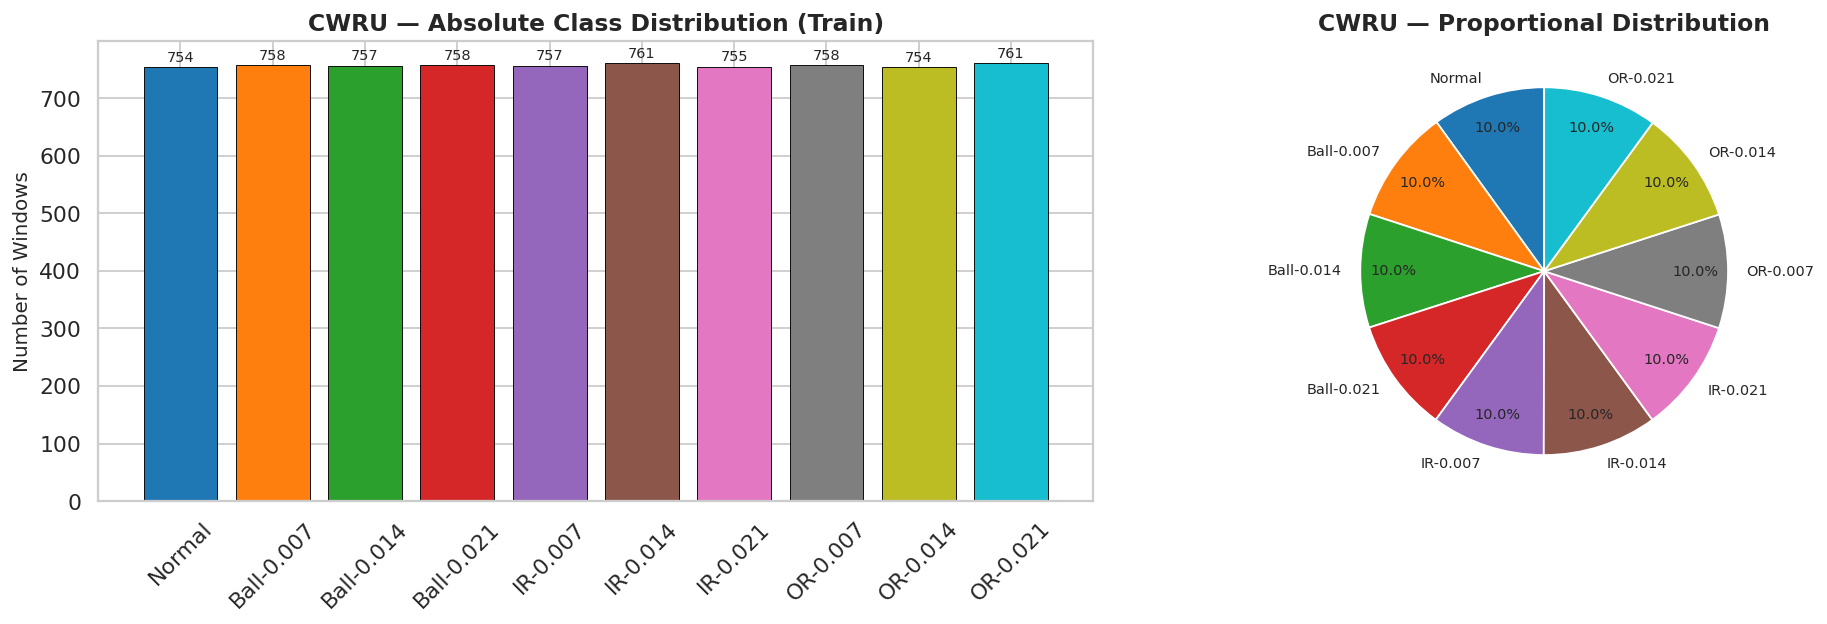

In [21]:
## ── 6.1  CWRU — Class Distribution & Imbalance Analysis ─────────────────────

CWRU_CLASS_NAMES = {
    0: "Normal", 1: "Ball-0.007", 2: "Ball-0.014", 3: "Ball-0.021",
    4: "IR-0.007", 5: "IR-0.014", 6: "IR-0.021",
    7: "OR-0.007", 8: "OR-0.014", 9: "OR-0.021",
}

cwru_y_np = np.array(cwru_y)  # materialise from mmap
cwru_counts = Counter(cwru_y_np)
cwru_class_df = pd.DataFrame([
    {"Label": k, "Class Name": CWRU_CLASS_NAMES[k], "Samples": cwru_counts[k]}
    for k in sorted(cwru_counts)
])
cwru_class_df["Proportion (%)"] = (cwru_class_df["Samples"] / cwru_class_df["Samples"].sum() * 100).round(2)
cwru_class_df["Imbalance Ratio (vs min)"] = (cwru_class_df["Samples"] / cwru_class_df["Samples"].min()).round(2)

print("CWRU — Per-Class Sample Counts (Training Split)")
print("=" * 75)
display(cwru_class_df.style.hide(axis='index'))

# Imbalance metrics
max_count = cwru_class_df["Samples"].max()
min_count = cwru_class_df["Samples"].min()
print(f"\nMax/Min imbalance ratio:  {max_count/min_count:.2f}x")
print(f"Majority class:           {CWRU_CLASS_NAMES[cwru_class_df.loc[cwru_class_df['Samples'].idxmax(), 'Label']]}  ({max_count:,} samples)")
print(f"Minority class:           {CWRU_CLASS_NAMES[cwru_class_df.loc[cwru_class_df['Samples'].idxmin(), 'Label']]}  ({min_count:,} samples)")

# ── Bar Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolute counts
bars = axes[0].bar(cwru_class_df["Class Name"], cwru_class_df["Samples"],
                   color=[COLORS[i] for i in range(10)], edgecolor='black', linewidth=0.5)
axes[0].set_title("CWRU — Absolute Class Distribution (Train)", fontweight='bold')
axes[0].set_ylabel("Number of Windows")
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, cwru_class_df["Samples"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{val:,}", ha='center', va='bottom', fontsize=8)

# Proportional
axes[1].pie(cwru_class_df["Samples"], labels=cwru_class_df["Class Name"],
            autopct='%1.1f%%', colors=[COLORS[i] for i in range(10)],
            startangle=90, pctdistance=0.82, textprops={'fontsize': 8})
axes[1].set_title("CWRU — Proportional Distribution", fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
## ── 6.2  CWRU — Per-Class Statistical Summary ───────────────────────────────
# Compute key time-domain features per class: mean, std, RMS, kurtosis, skewness,
# crest factor, peak-to-peak. These are the same features PHM engineers check.

cwru_stat_rows = []
for lbl in sorted(np.unique(cwru_y_np)):
    idx = np.where(cwru_y_np == lbl)[0]
    # Subsample up to 2000 for speed; squeeze channel dim
    sub = np.array(cwru_X[idx[:2000], :, 0])
    rms_vals    = np.sqrt(np.mean(sub**2, axis=1))
    kurt_vals   = sp_stats.kurtosis(sub, axis=1, fisher=True)
    skew_vals   = sp_stats.skew(sub, axis=1)
    p2p_vals    = np.ptp(sub, axis=1)
    crest_vals  = np.max(np.abs(sub), axis=1) / (rms_vals + 1e-12)

    cwru_stat_rows.append({
        "Class": CWRU_CLASS_NAMES[lbl],
        "n": len(idx),
        "Mean μ": f"{sub.mean():.4f}",
        "Std σ": f"{sub.std():.4f}",
        "RMS": f"{rms_vals.mean():.4f}",
        "Kurtosis": f"{kurt_vals.mean():.3f}",
        "Skewness": f"{skew_vals.mean():.3f}",
        "Peak-to-Peak": f"{p2p_vals.mean():.3f}",
        "Crest Factor": f"{crest_vals.mean():.3f}",
    })

cwru_stats_df = pd.DataFrame(cwru_stat_rows)
print("CWRU — Per-Class Time-Domain Statistical Summary")
print("=" * 110)
display(cwru_stats_df.style.hide(axis='index'))

CWRU — Per-Class Time-Domain Statistical Summary


Class,n,Mean μ,Std σ,RMS,Kurtosis,Skewness,Peak-to-Peak,Crest Factor
Normal,754,-0.0070,0.1423,0.1423,-0.084,-0.173,0.902,3.442
Ball-0.007,758,0.0072,0.3057,0.3050,-0.010,0.007,1.953,3.356
Ball-0.014,757,-0.0095,0.3243,0.3058,2.871,0.056,2.804,4.708
Ball-0.021,758,-0.0083,0.4696,0.4383,0.177,-0.003,2.906,3.347
IR-0.007,757,0.0110,0.6062,0.6060,4.340,-0.090,5.981,5.130
IR-0.014,761,0.0340,0.4267,0.4268,1.240,-0.005,3.616,4.532
IR-0.021,755,-0.0096,1.3261,1.3205,0.720,0.032,9.755,3.851
OR-0.007,758,-0.0079,2.3110,2.3050,3.857,0.072,21.094,4.658
OR-0.014,754,-0.0079,0.2972,0.2956,0.083,-0.003,1.927,3.385
OR-0.021,761,-0.0024,1.3503,1.3199,13.770,-0.312,17.494,6.908


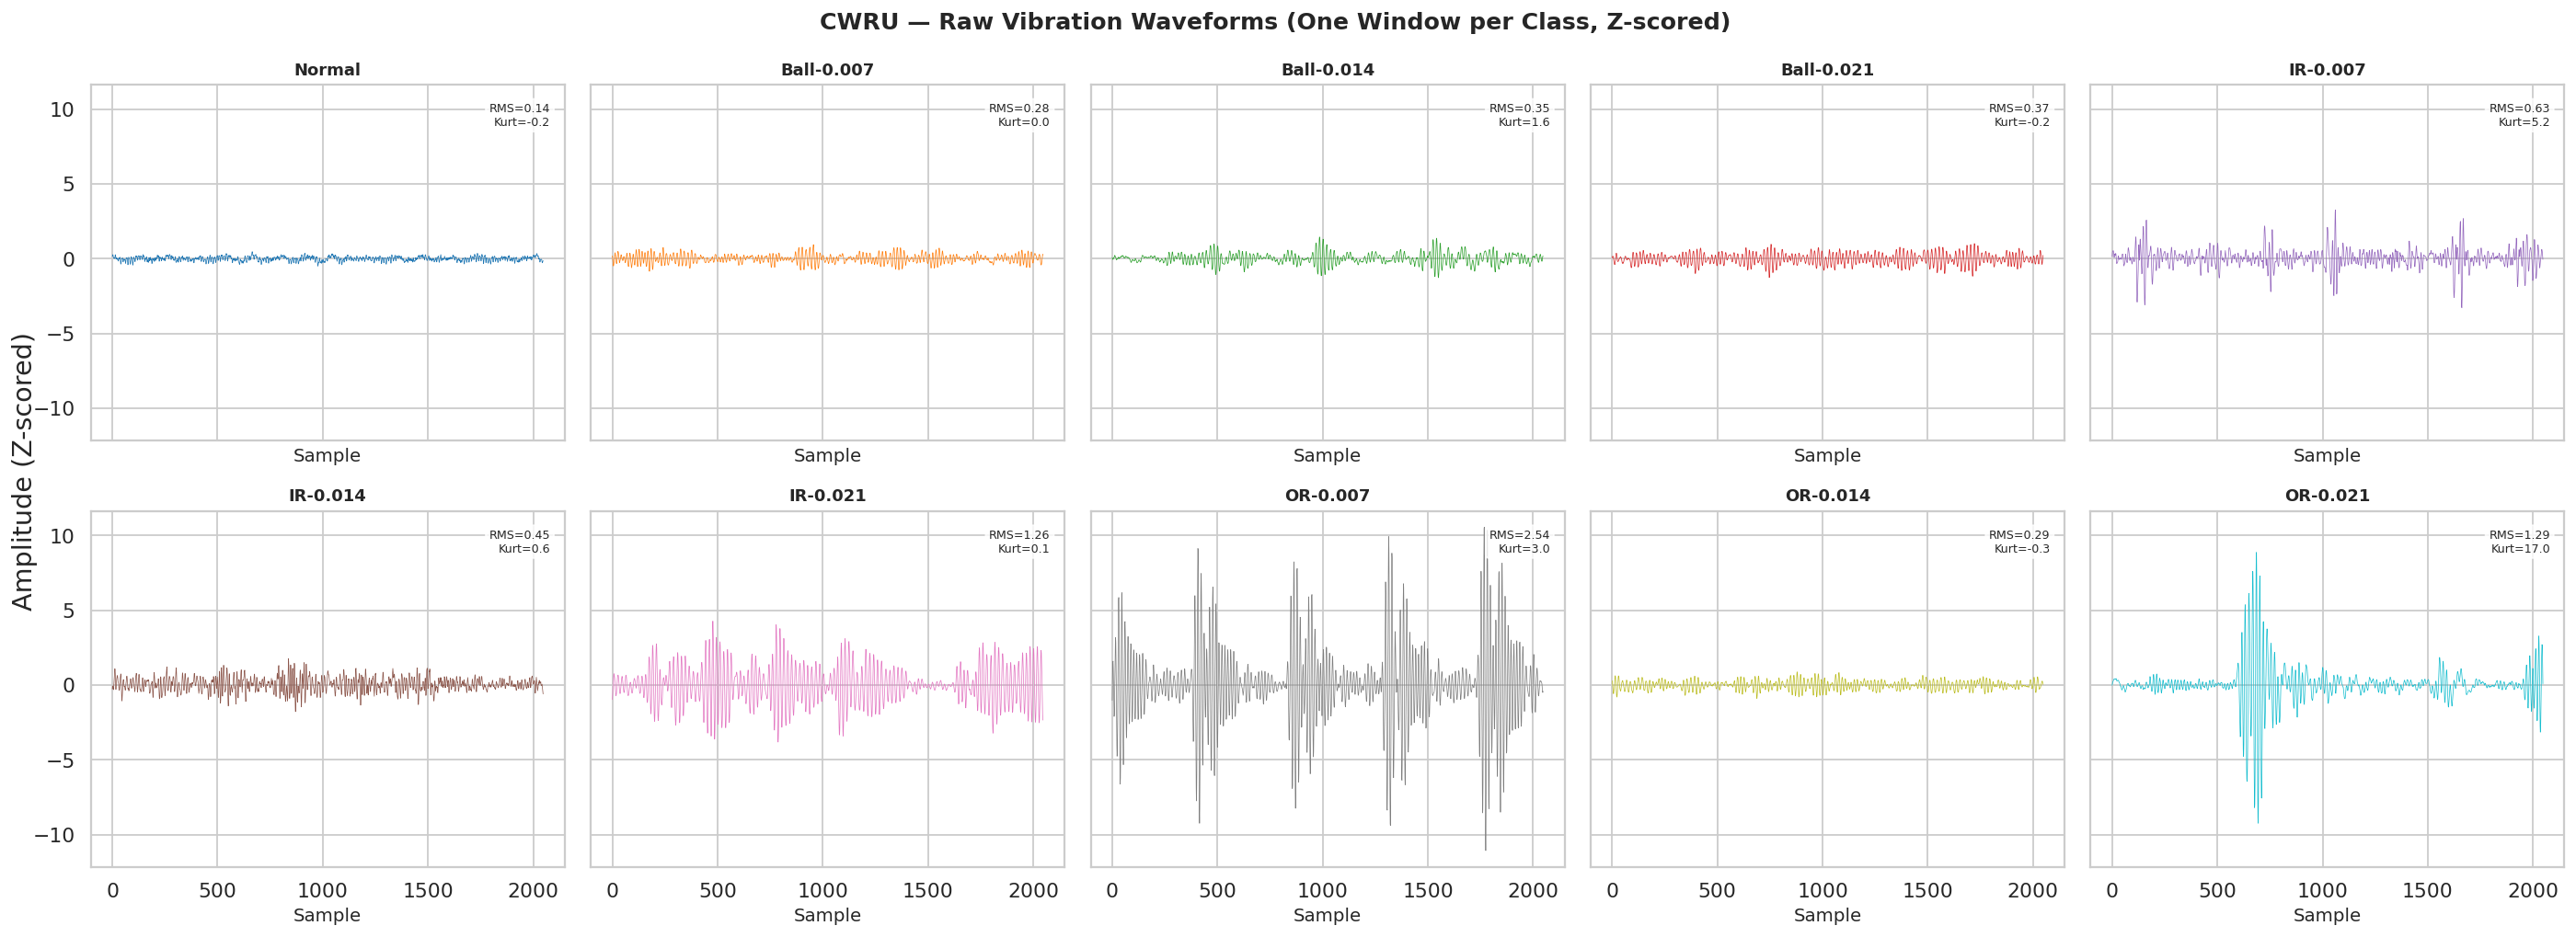

In [23]:
## ── 6.3  CWRU — Raw Waveform Overlay per Class ──────────────────────────────
# One representative window per class overlaid on the same axes, plus a 
# zoomed-in inset on 200 samples to reveal the high-frequency modulation.

fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True, sharey=True)
axes = axes.flatten()
for lbl in range(10):
    ax = axes[lbl]
    idx = np.where(cwru_y_np == lbl)[0]
    sig = np.array(cwru_X[idx[0], :, 0])
    ax.plot(sig, linewidth=0.4, color=COLORS[lbl])
    ax.set_title(CWRU_CLASS_NAMES[lbl], fontsize=10, fontweight='bold')
    ax.set_xlabel("Sample")
    # Add annotation with key stats
    rms = np.sqrt(np.mean(sig**2))
    kurt = sp_stats.kurtosis(sig, fisher=True)
    ax.text(0.97, 0.95, f"RMS={rms:.2f}\nKurt={kurt:.1f}",
            transform=ax.transAxes, fontsize=7, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle("CWRU — Raw Vibration Waveforms (One Window per Class, Z-scored)", fontsize=14, fontweight='bold')
fig.supylabel("Amplitude (Z-scored)")
plt.tight_layout()
plt.show()

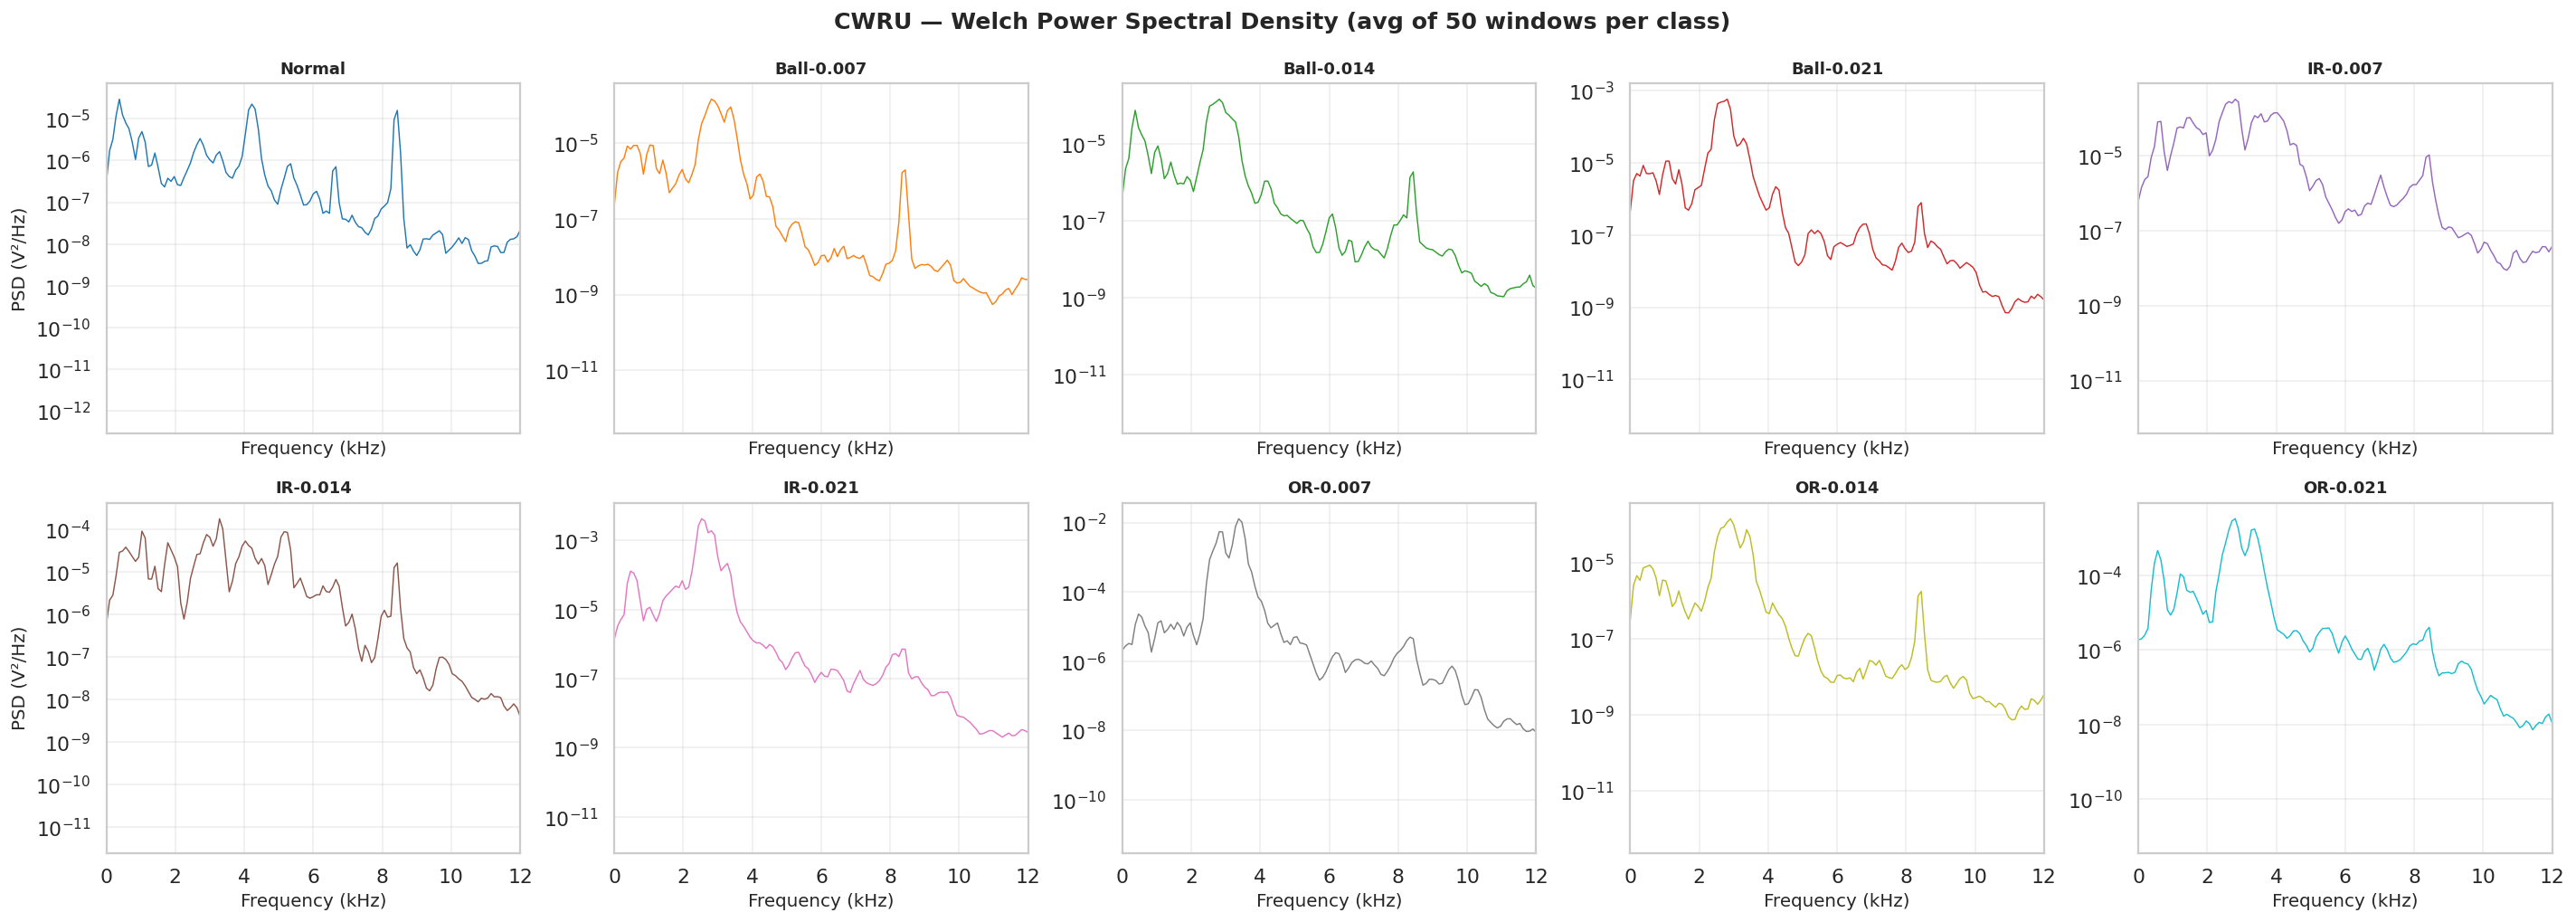

In [24]:
## ── 6.4  CWRU — Frequency-Domain (Power Spectral Density) per Class ──────────
# Welch PSD reveals which frequency bands each fault type excites.
# Key frequencies: BPFO (~3.5× shaft), BPFI (~5.4× shaft), BSF (~2.4× shaft).
# We use fs=48000 Hz (DE channel sampling rate).

FS_CWRU = 48000  # Hz
NPERSEG = 512    # Welch segment length

fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True)
axes = axes.flatten()
for lbl in range(10):
    ax = axes[lbl]
    idx = np.where(cwru_y_np == lbl)[0]
    # Average PSD over 50 random windows for a representative envelope
    psd_avg = None
    n_avg = min(50, len(idx))
    for j in range(n_avg):
        sig = np.array(cwru_X[idx[j], :, 0])
        freqs, psd = welch(sig, fs=FS_CWRU, nperseg=NPERSEG)
        psd_avg = psd if psd_avg is None else psd_avg + psd
    psd_avg /= n_avg

    ax.semilogy(freqs / 1000, psd_avg, linewidth=0.8, color=COLORS[lbl])
    ax.set_title(CWRU_CLASS_NAMES[lbl], fontsize=10, fontweight='bold')
    ax.set_xlabel("Frequency (kHz)")
    ax.set_xlim(0, 12)  # Show up to 12 kHz
    if lbl % 5 == 0:
        ax.set_ylabel("PSD (V²/Hz)")
    ax.grid(True, alpha=0.3)

fig.suptitle("CWRU — Welch Power Spectral Density (avg of 50 windows per class)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2039661/3445695460.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cwru_feat_df, x="Class", y=metric, ax=ax, palette="tab10",
/tmp/ipykernel_2039661/3445695460.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cwru_feat_df, x="Class", y=metric, ax=ax, palette="tab10",
/tmp/ipykernel_2039661/3445695460.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cwru_feat_df, x="Class", y=metric, ax=ax, palette="tab10",
/tmp/ipykernel_2039661/3445695460.py:24: FutureWarning: 

Passing `palette` without assigning 

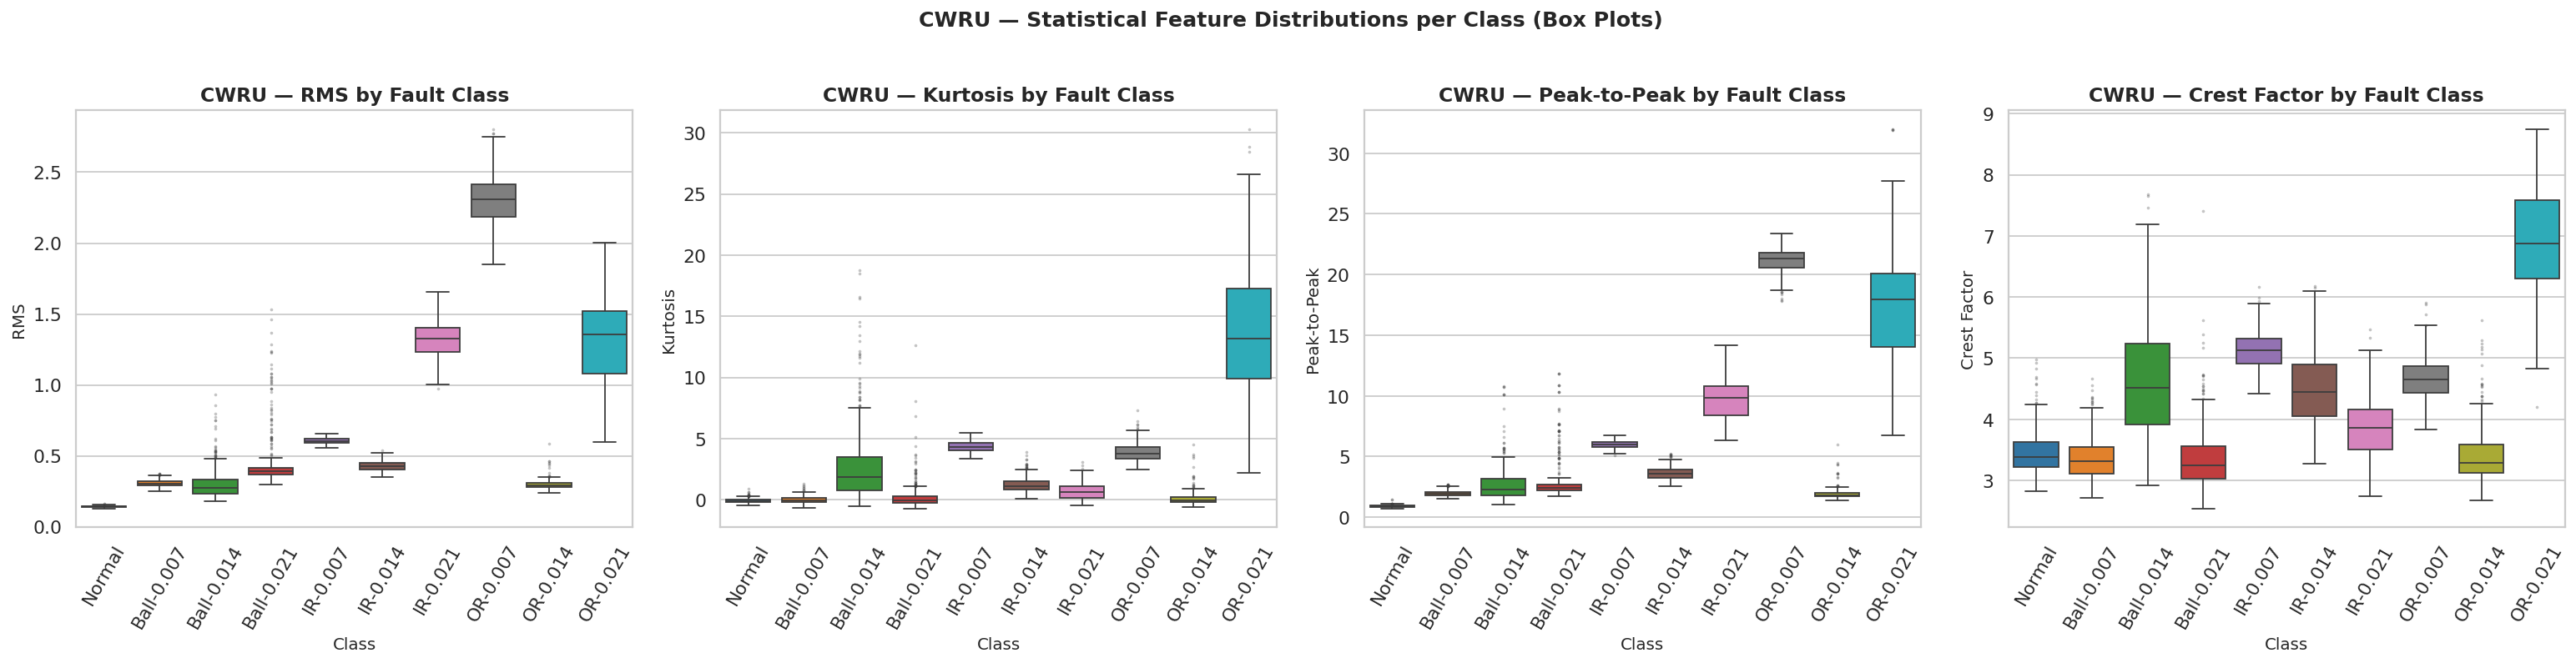

In [25]:
## ── 6.5  CWRU — Box-Whisker Plot of Key Statistical Features per Class ───────
# RMS, Kurtosis, Peak-to-Peak, Crest Factor distributions per class.
# This directly shows how separable the classes are with classical features.

n_per_class = 500  # subsample for speed
feat_rows = []
for lbl in sorted(np.unique(cwru_y_np)):
    idx = np.where(cwru_y_np == lbl)[0][:n_per_class]
    sub = np.array(cwru_X[idx, :, 0])
    rms  = np.sqrt(np.mean(sub**2, axis=1))
    kurt = sp_stats.kurtosis(sub, axis=1, fisher=True)
    p2p  = np.ptp(sub, axis=1)
    crest = np.max(np.abs(sub), axis=1) / (rms + 1e-12)
    for i in range(len(idx)):
        feat_rows.append({
            "Class": CWRU_CLASS_NAMES[lbl], "RMS": rms[i],
            "Kurtosis": kurt[i], "Peak-to-Peak": p2p[i], "Crest Factor": crest[i]
        })

cwru_feat_df = pd.DataFrame(feat_rows)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, metric in zip(axes, ["RMS", "Kurtosis", "Peak-to-Peak", "Crest Factor"]):
    sns.boxplot(data=cwru_feat_df, x="Class", y=metric, ax=ax, palette="tab10",
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(f"CWRU — {metric} by Fault Class", fontweight='bold')
    ax.tick_params(axis='x', rotation=60)
fig.suptitle("CWRU — Statistical Feature Distributions per Class (Box Plots)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

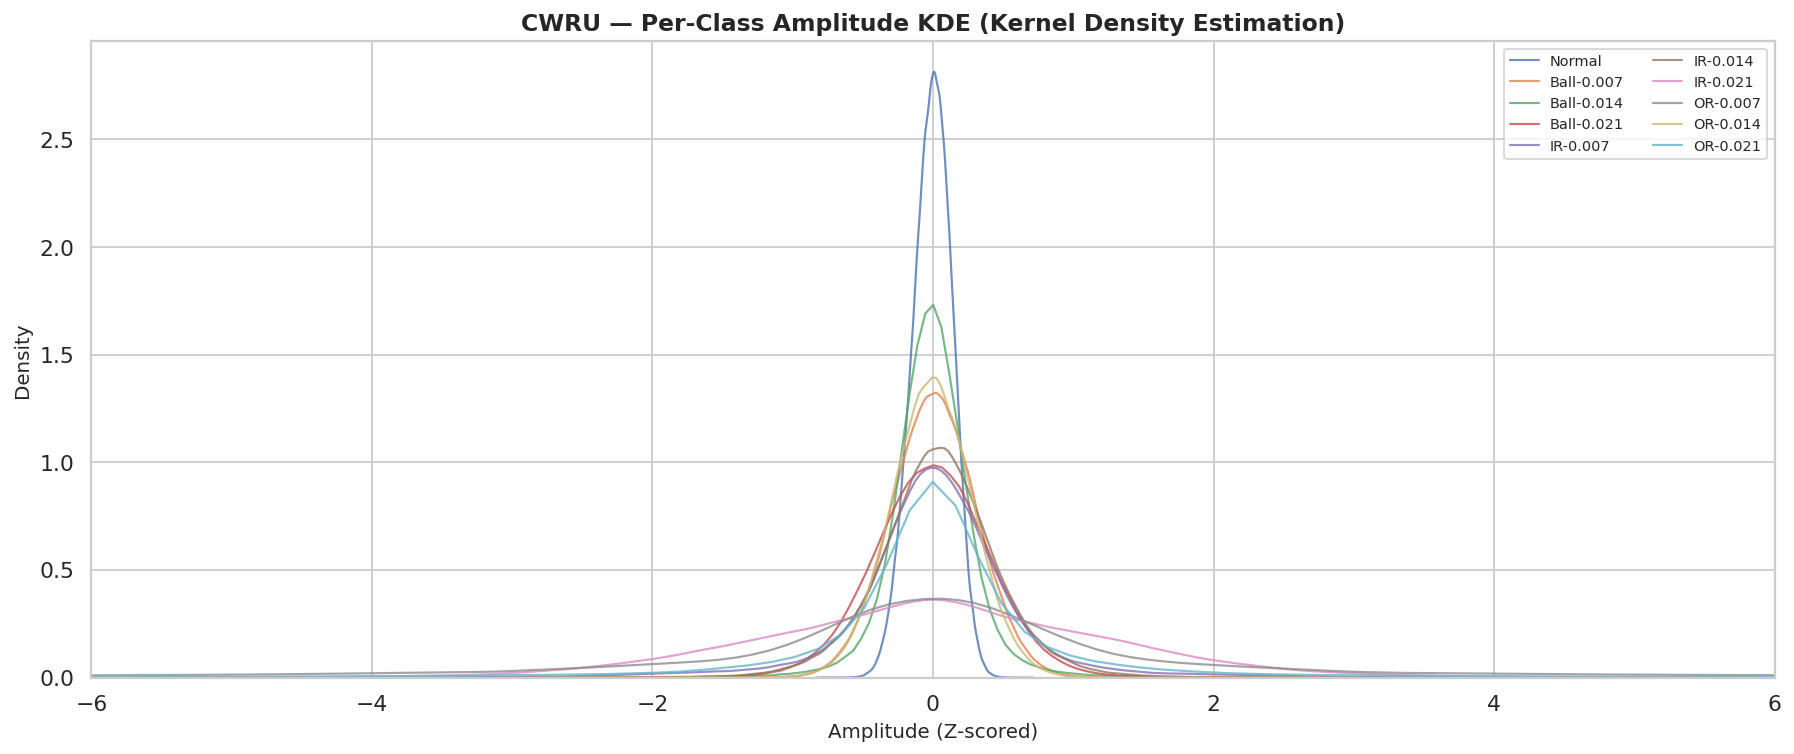

In [26]:
## ── 6.6  CWRU — Amplitude Distribution (KDE) per Class ──────────────────────
# Global amplitude distribution of every sample point within each class.
# Healthy bearings: tight Gaussian.  Damaged: heavier tails.

fig, ax = plt.subplots(figsize=(14, 6))
for lbl in range(10):
    idx = np.where(cwru_y_np == lbl)[0][:300]
    vals = np.array(cwru_X[idx, :, 0]).flatten()
    sns.kdeplot(vals, ax=ax, label=CWRU_CLASS_NAMES[lbl], linewidth=1.2, alpha=0.8)
ax.set_title("CWRU — Per-Class Amplitude KDE (Kernel Density Estimation)", fontweight='bold')
ax.set_xlabel("Amplitude (Z-scored)")
ax.set_ylabel("Density")
ax.legend(ncol=2, fontsize=8)
ax.set_xlim(-6, 6)
plt.tight_layout()
plt.show()

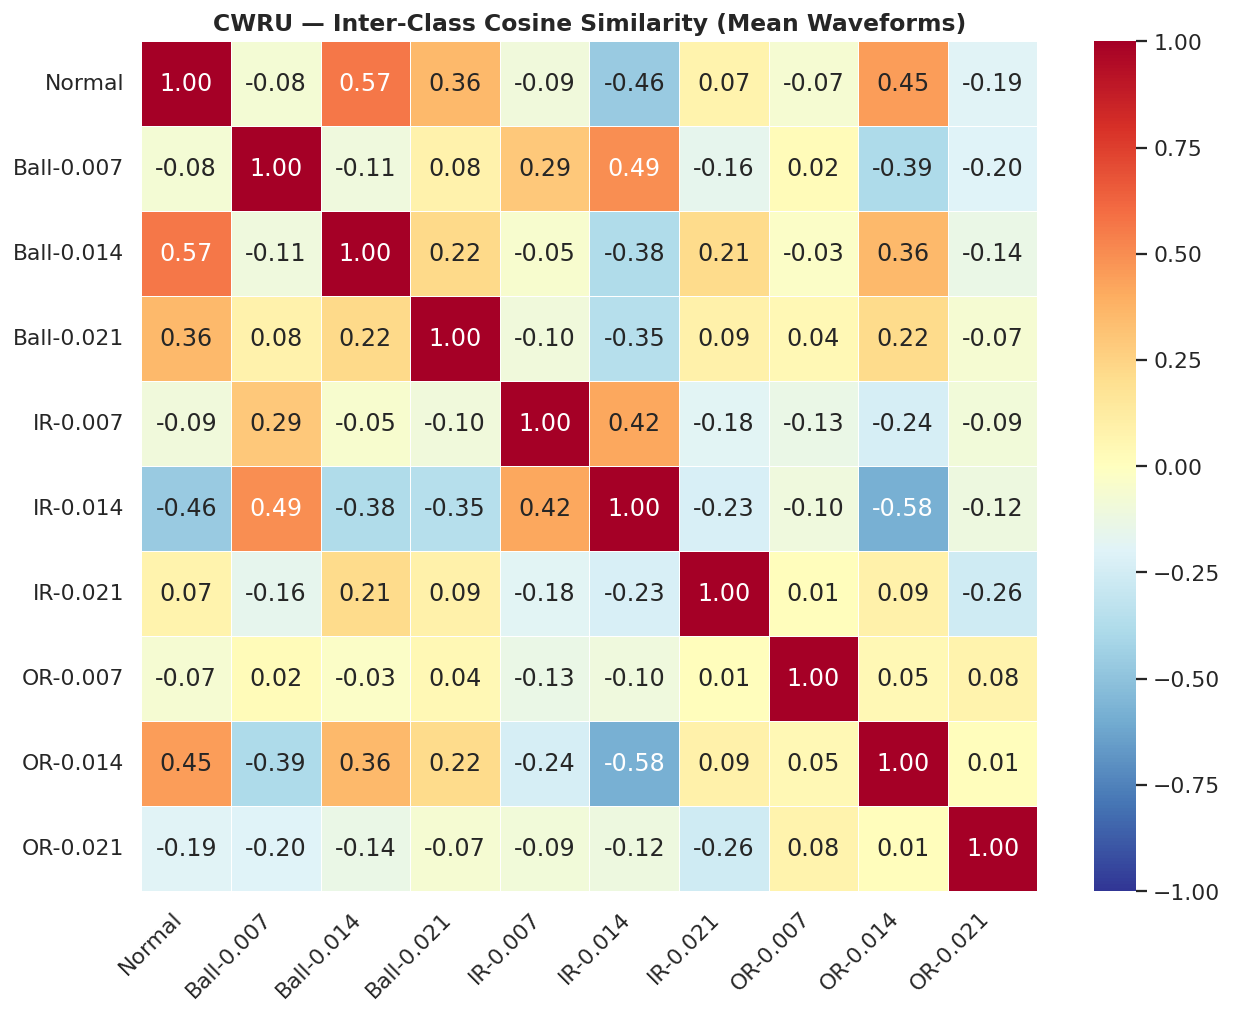

Interpretation: Values close to 1.0 = nearly identical mean waveforms → hard to distinguish.
Values close to 0 or negative = structurally different signals → easier classification.


In [27]:
## ── 6.7  CWRU — Correlation Heatmap (Inter-Class Feature Similarity) ─────────
# Build a 10×10 matrix where entry (i,j) = cosine similarity between the mean
# feature vectors of class i and j. This reveals which fault types the classifier
# will find hardest to distinguish (high similarity = confusion risk).

from sklearn.metrics.pairwise import cosine_similarity

# Mean waveform per class (first 500 windows each)
cwru_mean_vecs = []
for lbl in range(10):
    idx = np.where(cwru_y_np == lbl)[0][:500]
    cwru_mean_vecs.append(np.array(cwru_X[idx, :, 0]).mean(axis=0))
cwru_mean_vecs = np.array(cwru_mean_vecs)

sim_matrix = cosine_similarity(cwru_mean_vecs)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt=".2f",
            xticklabels=[CWRU_CLASS_NAMES[i] for i in range(10)],
            yticklabels=[CWRU_CLASS_NAMES[i] for i in range(10)],
            cmap="RdYlBu_r", vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("CWRU — Inter-Class Cosine Similarity (Mean Waveforms)", fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Interpretation: Values close to 1.0 = nearly identical mean waveforms → hard to distinguish.")
print("Values close to 0 or negative = structurally different signals → easier classification.")

---
---
# 7 — Paderborn Bearing Fault Dataset: In-Depth Analysis
> **Task:** 31-class bearing fault classification (6 Healthy K001–K006 + 11 Artificial Damage KA + 3 Artificial Damage KB + 11 Real Damage KI).
> **Signal:** Vibration channel 1 @ 64 kHz · Window = 4096 · Z-score normalised.
> **Scale:** ~614k total windows — the largest bearing classification dataset in our benchmark.

### What to look for:
- **Severe class imbalance** — 31 classes, but healthy vs. artificial vs. real damage categories may have very different populations.
- **Category-level clustering** — Do K (healthy), KA (artificial outer race), KB (artificial inner+outer), and KI (real damage) form natural clusters?
- **Frequency content differences** — Artificial damage creates sharper impulses than real-world wear.
- **Signal amplitude variation** — Real damage may show more complex, non-periodic modulation patterns.

In [28]:
## ── 7.1  Paderborn — Class Distribution & Category-Level Imbalance ───────────

# Map bearing names to damage categories
PB_CATEGORY = {}
pb_bearing_names = sorted(set(f"K{str(i).zfill(3)}" for i in range(1, 7))  # K001-K006 = Healthy
                          | set(["KA01","KA03","KA04","KA05","KA06","KA07","KA09",
                                 "KA15","KA16","KA22","KA30"])                # KA = Artificial outer race
                          | set(["KB23","KB24","KB27"])                        # KB = Artificial inner+outer
                          | set(["KI01","KI03","KI04","KI05","KI07","KI08",
                                 "KI14","KI16","KI17","KI18","KI21"]))        # KI = Real damage

# Build label → name map from the alphabetical order used during preprocessing
pb_sorted_bearings = sorted(PB_CATEGORY.keys()) if PB_CATEGORY else sorted(list(
    set([f"K{str(i).zfill(3)}" for i in range(1,7)] +
        ["KA01","KA03","KA04","KA05","KA06","KA07","KA09","KA15","KA16","KA22","KA30"] +
        ["KB23","KB24","KB27"] +
        ["KI01","KI03","KI04","KI05","KI07","KI08","KI14","KI16","KI17","KI18","KI21"])
))
PB_LABEL_MAP = {idx: name for idx, name in enumerate(pb_sorted_bearings)}
PB_NAME_MAP = {name: idx for idx, name in PB_LABEL_MAP.items()}

def pb_category(name):
    if name.startswith("KI"): return "Real Damage (KI)"
    elif name.startswith("KB"): return "Artificial Inner+Outer (KB)"
    elif name.startswith("KA"): return "Artificial Outer Race (KA)"
    else: return "Healthy (K)"

pb_y_np = np.array(pb_y)
pb_counts = Counter(pb_y_np)

pb_class_df = pd.DataFrame([
    {"Label": k, "Bearing": PB_LABEL_MAP.get(k, f"?{k}"),
     "Category": pb_category(PB_LABEL_MAP.get(k, "")),
     "Samples": pb_counts.get(k, 0)}
    for k in sorted(pb_counts)
])
pb_class_df["Proportion (%)"] = (pb_class_df["Samples"] / pb_class_df["Samples"].sum() * 100).round(3)
pb_class_df["Imbalance Ratio (vs min)"] = (pb_class_df["Samples"] / pb_class_df["Samples"].min()).round(2)

print("Paderborn — Per-Class Sample Counts (Training Split)")
print("=" * 100)
display(pb_class_df.style.hide(axis='index'))

# ── Category-level aggregation ──
pb_cat_df = pb_class_df.groupby("Category").agg(
    Classes=("Label", "count"),
    Total_Samples=("Samples", "sum"),
    Avg_per_Class=("Samples", "mean"),
    Min_per_Class=("Samples", "min"),
    Max_per_Class=("Samples", "max"),
).reset_index()
pb_cat_df["Share (%)"] = (pb_cat_df["Total_Samples"] / pb_cat_df["Total_Samples"].sum() * 100).round(2)

print("\n\nPaderborn — Category-Level Aggregation")
print("=" * 90)
display(pb_cat_df.style.hide(axis='index'))

# Print headline imbalance numbers
total_pb = pb_class_df["Samples"].sum()
print(f"\nTotal training windows: {total_pb:,}")
print(f"Max/Min per-class imbalance ratio: {pb_class_df['Samples'].max()/pb_class_df['Samples'].min():.2f}x")
print(f"Healthy vs Fault ratio: {pb_cat_df[pb_cat_df['Category'].str.contains('Healthy')]['Total_Samples'].sum()}"
      f" / {pb_cat_df[~pb_cat_df['Category'].str.contains('Healthy')]['Total_Samples'].sum()}"
      f" = {pb_cat_df[pb_cat_df['Category'].str.contains('Healthy')]['Total_Samples'].sum() / pb_cat_df[~pb_cat_df['Category'].str.contains('Healthy')]['Total_Samples'].sum():.3f}")

Paderborn — Per-Class Sample Counts (Training Split)


Label,Bearing,Category,Samples,Proportion (%),Imbalance Ratio (vs min)
0,K001,Healthy (K),15823,3.220000,1.000000
1,K002,Healthy (K),15855,3.227000,1.000000
2,K003,Healthy (K),15844,3.225000,1.000000
3,K004,Healthy (K),15822,3.220000,1.000000
4,K005,Healthy (K),15834,3.223000,1.000000
5,K006,Healthy (K),15832,3.222000,1.000000
6,KA01,Artificial Outer Race (KA),15835,3.223000,1.000000
7,KA03,Artificial Outer Race (KA),15960,3.248000,1.010000
8,KA04,Artificial Outer Race (KA),15817,3.219000,1.000000
9,KA05,Artificial Outer Race (KA),15853,3.227000,1.000000




Paderborn — Category-Level Aggregation


Category,Classes,Total_Samples,Avg_per_Class,Min_per_Class,Max_per_Class,Share (%)
Artificial Inner+Outer (KB),3,47554,15851.333333,15832,15876,9.680000
Artificial Outer Race (KA),11,174355,15850.454545,15817,15960,35.490000
Healthy (K),6,95010,15835.000000,15822,15855,19.340000
Real Damage (KI),11,174406,15855.090909,15816,15945,35.500000



Total training windows: 491,325
Max/Min per-class imbalance ratio: 1.01x
Healthy vs Fault ratio: 95010 / 396315 = 0.240


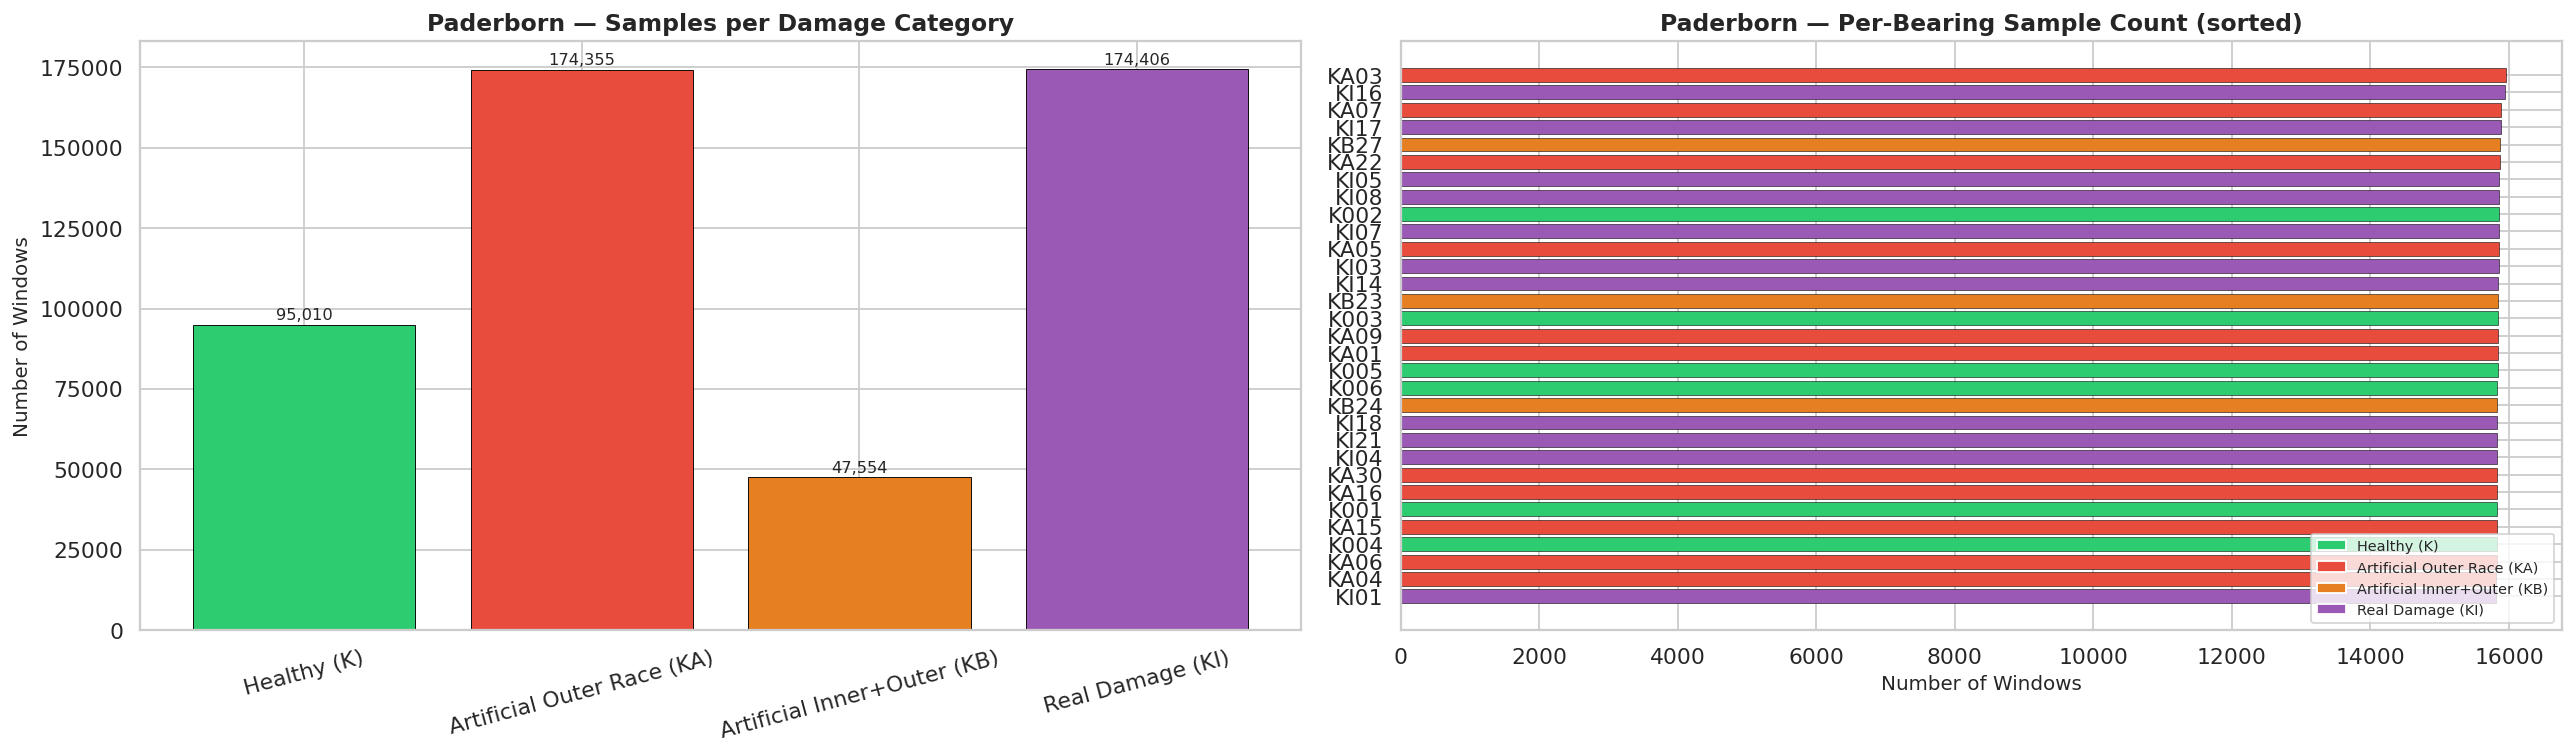

In [29]:
## ── 7.2  Paderborn — Category-Level & Per-Class Bar Charts ───────────────────

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Category-level bar chart
cat_colors = {"Healthy (K)": "#2ecc71", "Artificial Outer Race (KA)": "#e74c3c",
              "Artificial Inner+Outer (KB)": "#e67e22", "Real Damage (KI)": "#9b59b6"}
cat_order = ["Healthy (K)", "Artificial Outer Race (KA)", "Artificial Inner+Outer (KB)", "Real Damage (KI)"]
bars = axes[0].bar(pb_cat_df.set_index("Category").reindex(cat_order)["Total_Samples"].index,
                   pb_cat_df.set_index("Category").reindex(cat_order)["Total_Samples"].values,
                   color=[cat_colors.get(c, "grey") for c in cat_order], edgecolor='black', linewidth=0.5)
axes[0].set_title("Paderborn — Samples per Damage Category", fontweight='bold')
axes[0].set_ylabel("Number of Windows")
for bar, val in zip(bars, pb_cat_df.set_index("Category").reindex(cat_order)["Total_Samples"].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{val:,.0f}", ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# Per-class horizontal bar chart (sorted by count)
pb_sorted = pb_class_df.sort_values("Samples", ascending=True)
cat_map_colors = [cat_colors.get(pb_category(PB_LABEL_MAP.get(lbl, "")), "grey") for lbl in pb_sorted["Label"]]
axes[1].barh(pb_sorted["Bearing"], pb_sorted["Samples"], color=cat_map_colors, edgecolor='black', linewidth=0.3)
axes[1].set_title("Paderborn — Per-Bearing Sample Count (sorted)", fontweight='bold')
axes[1].set_xlabel("Number of Windows")
# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors[c], label=c) for c in cat_order]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [30]:
## ── 7.3  Paderborn — Per-Category Statistical Summary ────────────────────────
# Aggregate time-domain stats for each damage category (not per-class to keep
# the table readable with 31 classes).

pb_cat_stat_rows = []
for cat_name in cat_order:
    cat_labels = [lbl for lbl, name in PB_LABEL_MAP.items() if pb_category(name) == cat_name]
    idx = np.where(np.isin(pb_y_np, cat_labels))[0]
    sub = np.array(pb_X[idx[:3000], :, 0])  # subsample for speed

    rms_vals  = np.sqrt(np.mean(sub**2, axis=1))
    kurt_vals = sp_stats.kurtosis(sub, axis=1, fisher=True)
    skew_vals = sp_stats.skew(sub, axis=1)
    p2p_vals  = np.ptp(sub, axis=1)
    crest_vals = np.max(np.abs(sub), axis=1) / (rms_vals + 1e-12)

    pb_cat_stat_rows.append({
        "Category": cat_name,
        "n (total)": len(idx),
        "n (used)": len(sub),
        "Mean μ": f"{sub.mean():.4f}",
        "Std σ": f"{sub.std():.4f}",
        "RMS": f"{rms_vals.mean():.4f} ± {rms_vals.std():.4f}",
        "Kurtosis": f"{kurt_vals.mean():.2f} ± {kurt_vals.std():.2f}",
        "Skewness": f"{skew_vals.mean():.3f} ± {skew_vals.std():.3f}",
        "P2P": f"{p2p_vals.mean():.2f} ± {p2p_vals.std():.2f}",
        "Crest Factor": f"{crest_vals.mean():.2f} ± {crest_vals.std():.2f}",
    })

pb_cat_stats_df = pd.DataFrame(pb_cat_stat_rows)
print("Paderborn — Category-Level Time-Domain Statistics")
print("=" * 130)
display(pb_cat_stats_df.style.hide(axis='index'))

Paderborn — Category-Level Time-Domain Statistics


Category,n (total),n (used),Mean μ,Std σ,RMS,Kurtosis,Skewness,P2P,Crest Factor
Healthy (K),95010,3000,-0.0661,0.8447,0.7955 ± 0.2916,10.94 ± 7.65,0.013 ± 0.365,12.30 ± 5.45,8.26 ± 2.00
Artificial Outer Race (KA),174355,3000,0.0114,0.9138,0.8303 ± 0.3816,6.71 ± 7.41,0.044 ± 0.503,10.17 ± 4.36,7.03 ± 2.14
Artificial Inner+Outer (KB),47554,3000,-0.0138,1.6776,1.4574 ± 0.8309,3.91 ± 3.37,0.126 ± 0.229,16.34 ± 9.88,6.12 ± 1.48
Real Damage (KI),174406,3000,0.0286,0.8923,0.8134 ± 0.3679,7.12 ± 8.56,0.024 ± 0.414,10.73 ± 6.28,7.27 ± 2.44


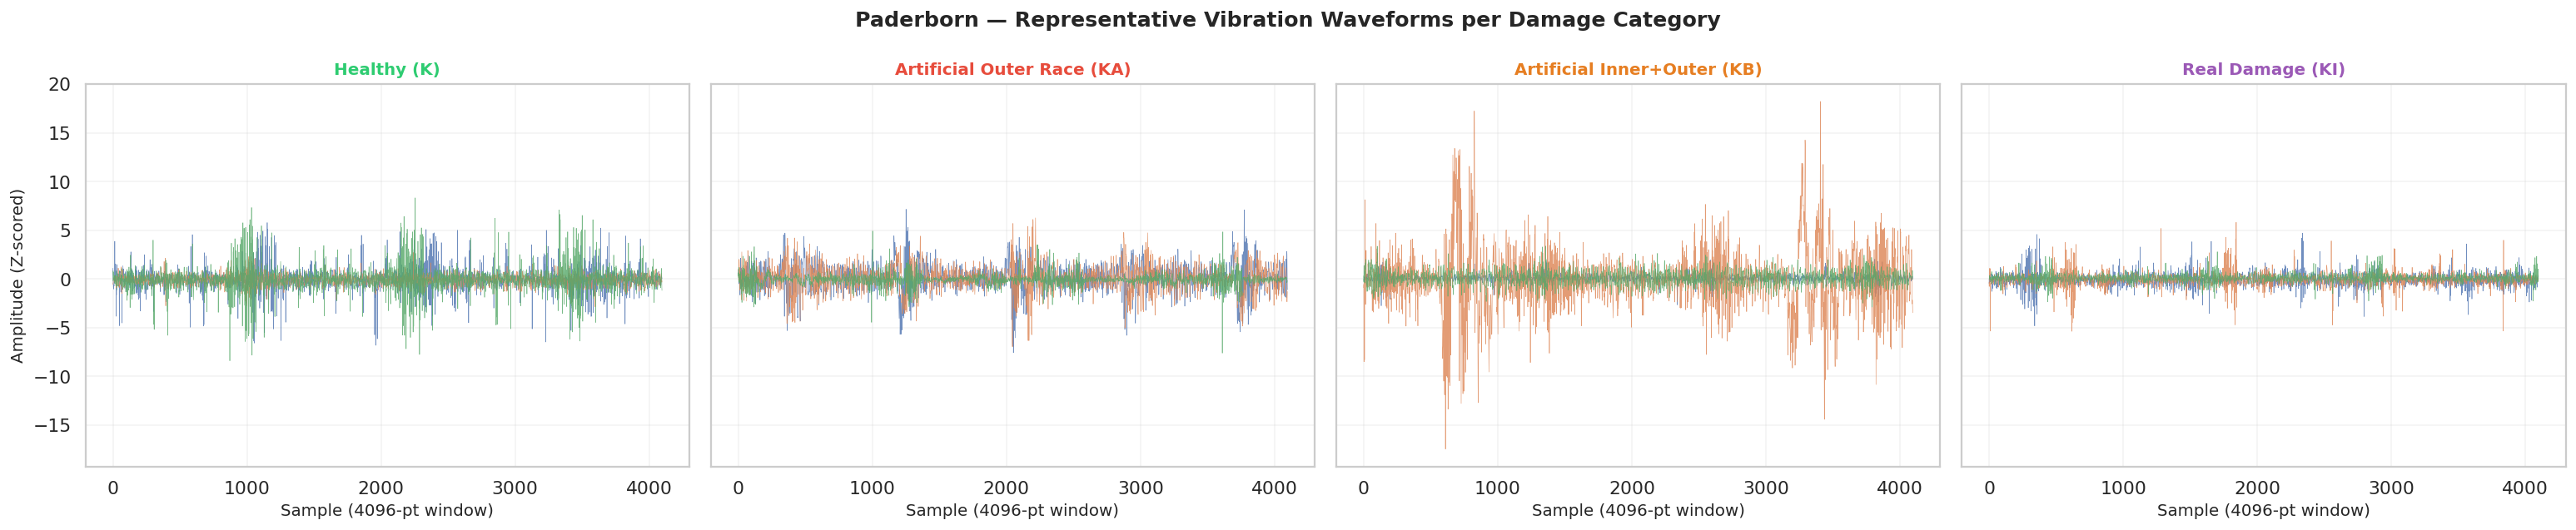

In [31]:
## ── 7.4  Paderborn — Representative Waveforms per Damage Category ─────────────
# 4 subplots — one per category — overlay 3 random windows each.

fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
for ax, cat_name in zip(axes, cat_order):
    cat_labels = [lbl for lbl, name in PB_LABEL_MAP.items() if pb_category(name) == cat_name]
    idx = np.where(np.isin(pb_y_np, cat_labels))[0]
    rng = np.random.RandomState(42)
    chosen = rng.choice(idx, size=min(3, len(idx)), replace=False)
    for j, ci in enumerate(chosen):
        sig = np.array(pb_X[ci, :, 0])
        ax.plot(sig, linewidth=0.35, alpha=0.8, label=f"idx={ci}" if j < 1 else None)
    ax.set_title(cat_name, fontsize=11, fontweight='bold', color=cat_colors[cat_name])
    ax.set_xlabel("Sample (4096-pt window)")
    if ax == axes[0]:
        ax.set_ylabel("Amplitude (Z-scored)")
    ax.grid(True, alpha=0.2)

fig.suptitle("Paderborn — Representative Vibration Waveforms per Damage Category", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

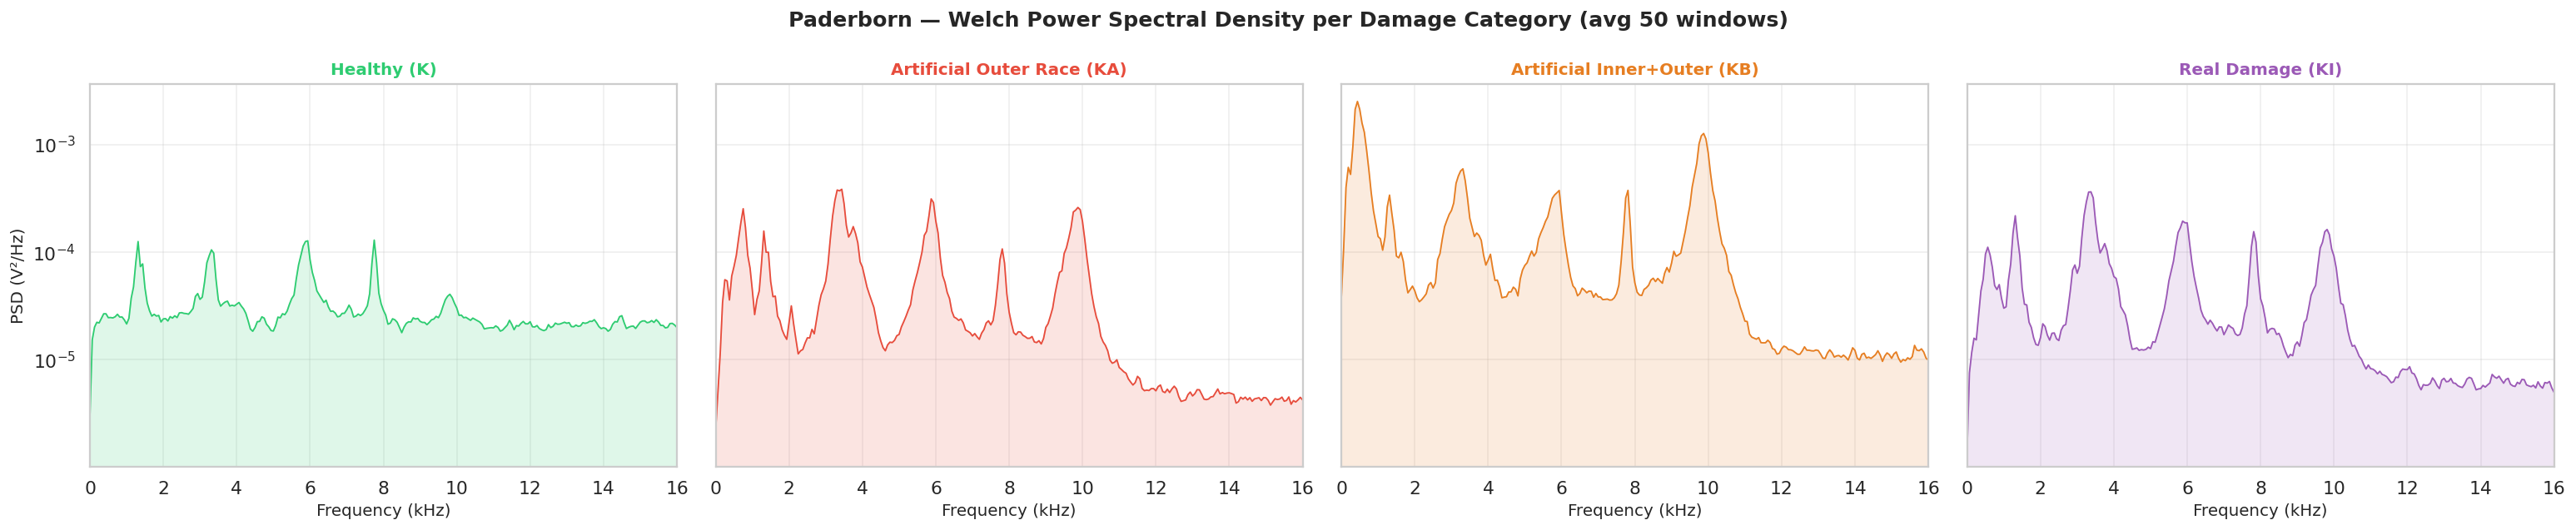

In [32]:
## ── 7.5  Paderborn — Frequency-Domain per Category ───────────────────────────
# Averaged Welch PSD (50 windows) per damage category.

FS_PB = 64000  # Hz
NPERSEG_PB = 1024

fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
for ax, cat_name in zip(axes, cat_order):
    cat_labels = [lbl for lbl, name in PB_LABEL_MAP.items() if pb_category(name) == cat_name]
    idx = np.where(np.isin(pb_y_np, cat_labels))[0]
    rng = np.random.RandomState(0)
    chosen = rng.choice(idx, size=min(50, len(idx)), replace=False)

    psd_avg = None
    for ci in chosen:
        sig = np.array(pb_X[ci, :, 0])
        freqs, psd = welch(sig, fs=FS_PB, nperseg=NPERSEG_PB)
        psd_avg = psd if psd_avg is None else psd_avg + psd
    psd_avg /= len(chosen)

    ax.semilogy(freqs / 1000, psd_avg, linewidth=1.0, color=cat_colors[cat_name])
    ax.fill_between(freqs / 1000, psd_avg, alpha=0.15, color=cat_colors[cat_name])
    ax.set_title(cat_name, fontsize=11, fontweight='bold', color=cat_colors[cat_name])
    ax.set_xlabel("Frequency (kHz)")
    ax.set_xlim(0, 16)
    if ax == axes[0]:
        ax.set_ylabel("PSD (V²/Hz)")
    ax.grid(True, alpha=0.3)

fig.suptitle("Paderborn — Welch Power Spectral Density per Damage Category (avg 50 windows)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2039661/2118662118.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pb_feat_df, x="Category", y=metric, ax=ax,
/tmp/ipykernel_2039661/2118662118.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pb_feat_df, x="Category", y=metric, ax=ax,
/tmp/ipykernel_2039661/2118662118.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pb_feat_df, x="Category", y=metric, ax=ax,
/tmp/ipykernel_2039661/2118662118.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14

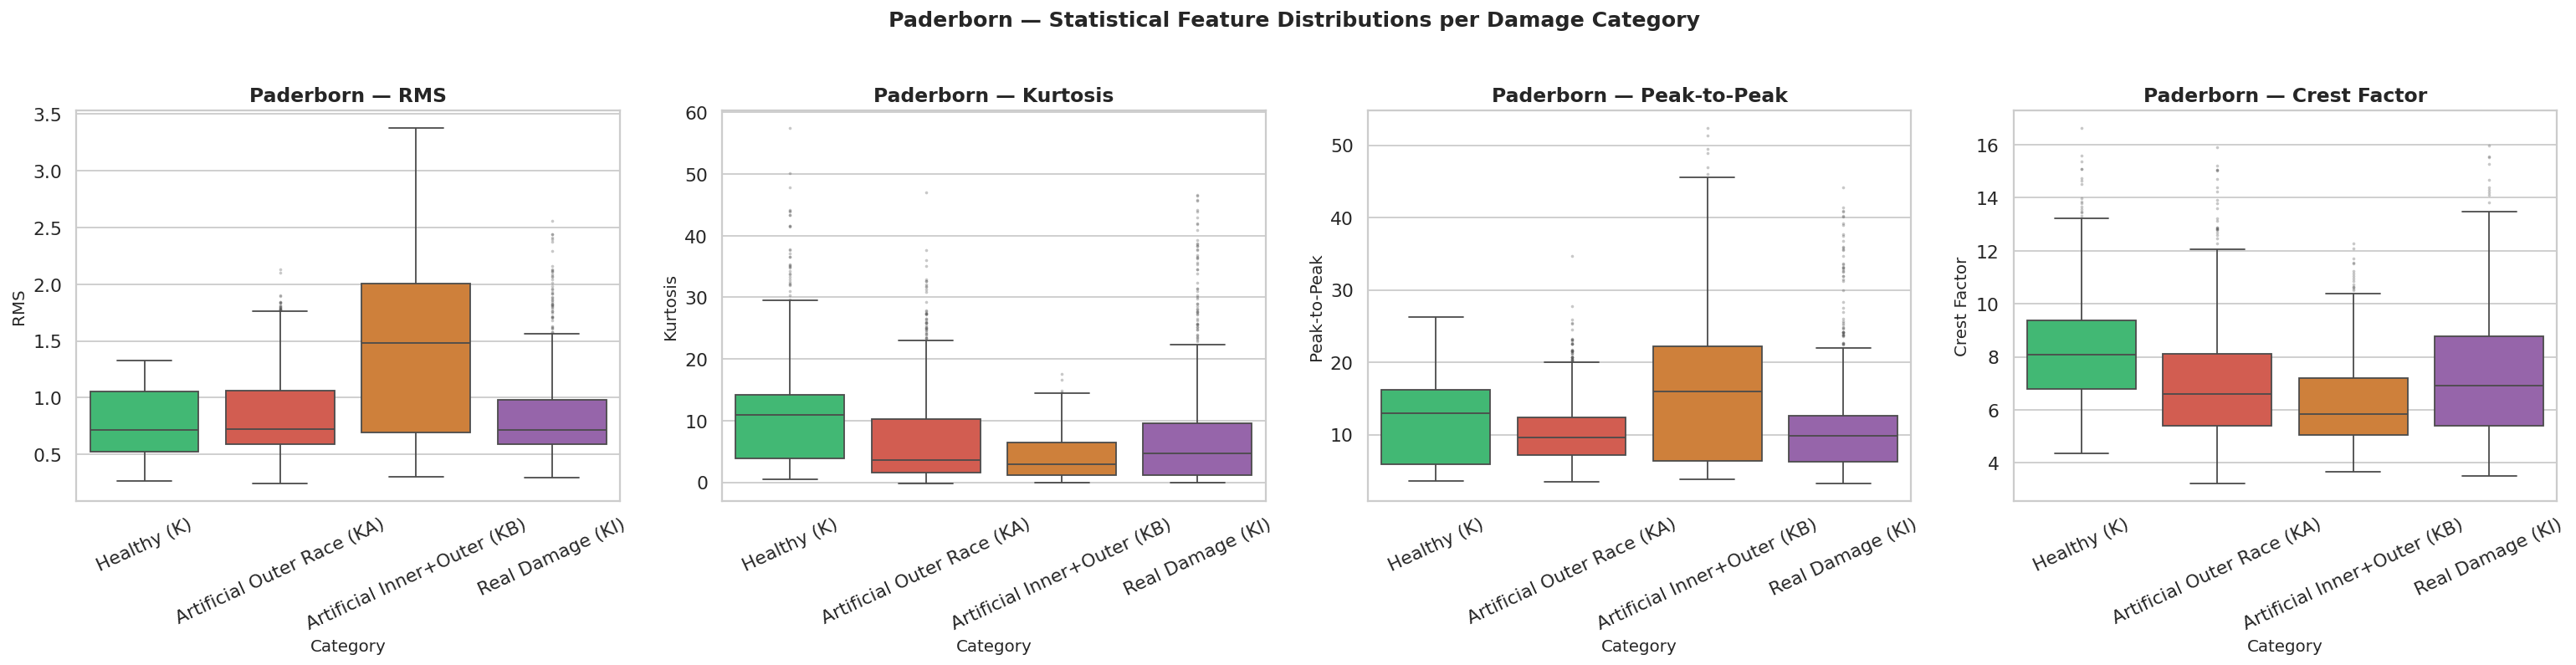

In [33]:
## ── 7.6  Paderborn — Box Plots of Statistical Features per Category ───────────

pb_feat_rows = []
for cat_name in cat_order:
    cat_labels = [lbl for lbl, name in PB_LABEL_MAP.items() if pb_category(name) == cat_name]
    idx = np.where(np.isin(pb_y_np, cat_labels))[0]
    rng = np.random.RandomState(42)
    chosen = rng.choice(idx, size=min(1000, len(idx)), replace=False)
    sub = np.array(pb_X[chosen, :, 0])

    rms  = np.sqrt(np.mean(sub**2, axis=1))
    kurt = sp_stats.kurtosis(sub, axis=1, fisher=True)
    p2p  = np.ptp(sub, axis=1)
    crest = np.max(np.abs(sub), axis=1) / (rms + 1e-12)
    for i in range(len(chosen)):
        pb_feat_rows.append({
            "Category": cat_name, "RMS": rms[i],
            "Kurtosis": kurt[i], "Peak-to-Peak": p2p[i], "Crest Factor": crest[i]
        })

pb_feat_df = pd.DataFrame(pb_feat_rows)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, metric in zip(axes, ["RMS", "Kurtosis", "Peak-to-Peak", "Crest Factor"]):
    sns.boxplot(data=pb_feat_df, x="Category", y=metric, ax=ax,
                palette=cat_colors, order=cat_order,
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(f"Paderborn — {metric}", fontweight='bold')
    ax.tick_params(axis='x', rotation=25)
fig.suptitle("Paderborn — Statistical Feature Distributions per Damage Category", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
---
# 8 — C-MAPSS Engine RUL Dataset: In-Depth Analysis
> **Task:** Remaining Useful Life (RUL) regression for turbofan engines.
> **Source:** NASA Prognostics Center of Excellence — FD001 sub-dataset.
> **Features:** 14 sensor channels per time step · Window = 30 cycles · max_rul = 125 (piece-wise linear degradation).

### What to look for:
- **RUL distribution** — Is it uniform, skewed, or dominated by near-failure samples (low RUL)?
- **Sensor degradation trajectories** — Which sensors show clear monotonic trends as engines approach failure?
- **Sensor correlation** — Co-evolving sensors may be redundant; uncorrelated sensors add complementary information.
- **Health index curvature** — The piece-wise linear model clips RUL at 125 cycles; look for a flat → declining pattern.
- **Operational regime effects** — Different flight conditions modulate sensor readings, adding noise to the degradation signal.

C-MAPSS FD001 — Dataset Shape Summary
  Samples (windows):    13,818
  Window length:        14 cycles
  Sensor channels:      30
  RUL range:            [1, 125]
  RUL mean ± std:       80.2 ± 41.4
  RUL median:           87.0


Metric,Value
Samples,13818
Window,14
Channels,30
RUL Min,1.000000
RUL Max,125.000000
RUL Mean,80.18
RUL Std,41.41
RUL Median,87.000000
RUL Q25,44.000000
RUL Q75,125.000000


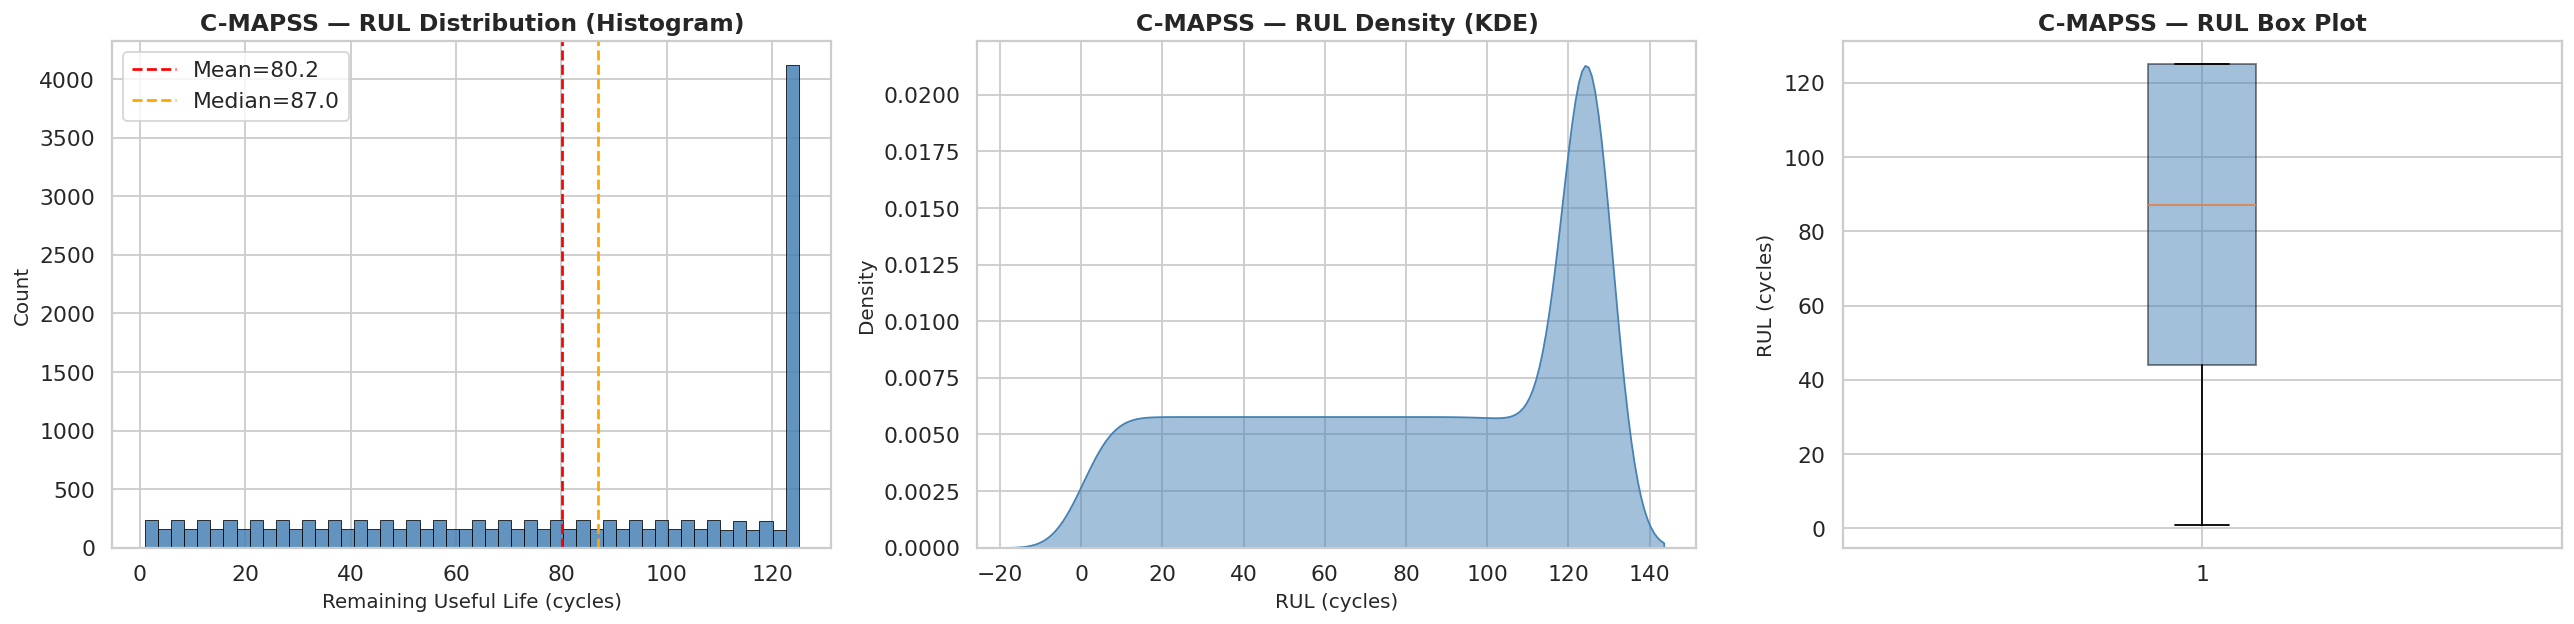


C-MAPSS — RUL Binned Distribution (regression imbalance diagnostic)
      0-25:  1,920 samples  ( 13.9%)  █████████████
     25-50:  2,000 samples  ( 14.5%)  ██████████████
     50-75:  2,000 samples  ( 14.5%)  ██████████████
    75-100:  2,000 samples  ( 14.5%)  ██████████████
   100-125:  1,928 samples  ( 14.0%)  █████████████
      125+:  3,970 samples  ( 28.7%)  ████████████████████████████


In [7]:
## ── 8.1  C-MAPSS — Dataset Overview & RUL Distribution ──────────────────────
# Extract from the rul_data dict (loaded in cell 4.1)

if "CMAPSS" in rul_data:
    cmapss_X = rul_data["CMAPSS"]["features"]  # (N, 30, 14)
    cmapss_y = rul_data["CMAPSS"]["targets"]    # (N,)
    n_samples, win_len, n_sensors = cmapss_X.shape

    print("C-MAPSS FD001 — Dataset Shape Summary")
    print("=" * 60)
    print(f"  Samples (windows):    {n_samples:,}")
    print(f"  Window length:        {win_len} cycles")
    print(f"  Sensor channels:      {n_sensors}")
    print(f"  RUL range:            [{cmapss_y.min():.0f}, {cmapss_y.max():.0f}]")
    print(f"  RUL mean ± std:       {cmapss_y.mean():.1f} ± {cmapss_y.std():.1f}")
    print(f"  RUL median:           {np.median(cmapss_y):.1f}")

    # Build DataFrame summary
    cmapss_summary = pd.DataFrame({
        "Metric": ["Samples", "Window", "Channels", "RUL Min", "RUL Max",
                    "RUL Mean", "RUL Std", "RUL Median", "RUL Q25", "RUL Q75"],
        "Value": [n_samples, win_len, n_sensors, cmapss_y.min(), cmapss_y.max(),
                  f"{cmapss_y.mean():.2f}", f"{cmapss_y.std():.2f}", np.median(cmapss_y),
                  np.percentile(cmapss_y, 25), np.percentile(cmapss_y, 75)]
    })
    display(cmapss_summary.style.hide(axis='index'))

    # ── RUL Distribution ──
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Histogram
    axes[0].hist(cmapss_y, bins=50, color='steelblue', edgecolor='black', linewidth=0.5, alpha=0.85)
    axes[0].axvline(cmapss_y.mean(), color='red', linestyle='--', label=f'Mean={cmapss_y.mean():.1f}')
    axes[0].axvline(np.median(cmapss_y), color='orange', linestyle='--', label=f'Median={np.median(cmapss_y):.1f}')
    axes[0].set_title("C-MAPSS — RUL Distribution (Histogram)", fontweight='bold')
    axes[0].set_xlabel("Remaining Useful Life (cycles)")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # KDE
    sns.kdeplot(cmapss_y, ax=axes[1], fill=True, color='steelblue', alpha=0.5)
    axes[1].set_title("C-MAPSS — RUL Density (KDE)", fontweight='bold')
    axes[1].set_xlabel("RUL (cycles)")

    # Box plot
    axes[2].boxplot(cmapss_y, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[2].set_title("C-MAPSS — RUL Box Plot", fontweight='bold')
    axes[2].set_ylabel("RUL (cycles)")

    plt.tight_layout()
    plt.show()

    # ── RUL Binned Distribution (for understanding data balance in regression) ──
    bins_rul = [0, 25, 50, 75, 100, 125, 200]
    bin_labels = ["0-25", "25-50", "50-75", "75-100", "100-125", "125+"]
    cmapss_binned = pd.cut(cmapss_y, bins=bins_rul, labels=bin_labels, right=False)
    bin_counts = cmapss_binned.value_counts().sort_index()
    print("\nC-MAPSS — RUL Binned Distribution (regression imbalance diagnostic)")
    print("=" * 50)
    for b, c in bin_counts.items():
        pct = c / len(cmapss_y) * 100
        bar = "█" * int(pct)
        print(f"  {b:>8s}:  {c:>5,} samples  ({pct:5.1f}%)  {bar}")
else:
    print("⚠️ CMAPSS not loaded — run cell 4.1 first")

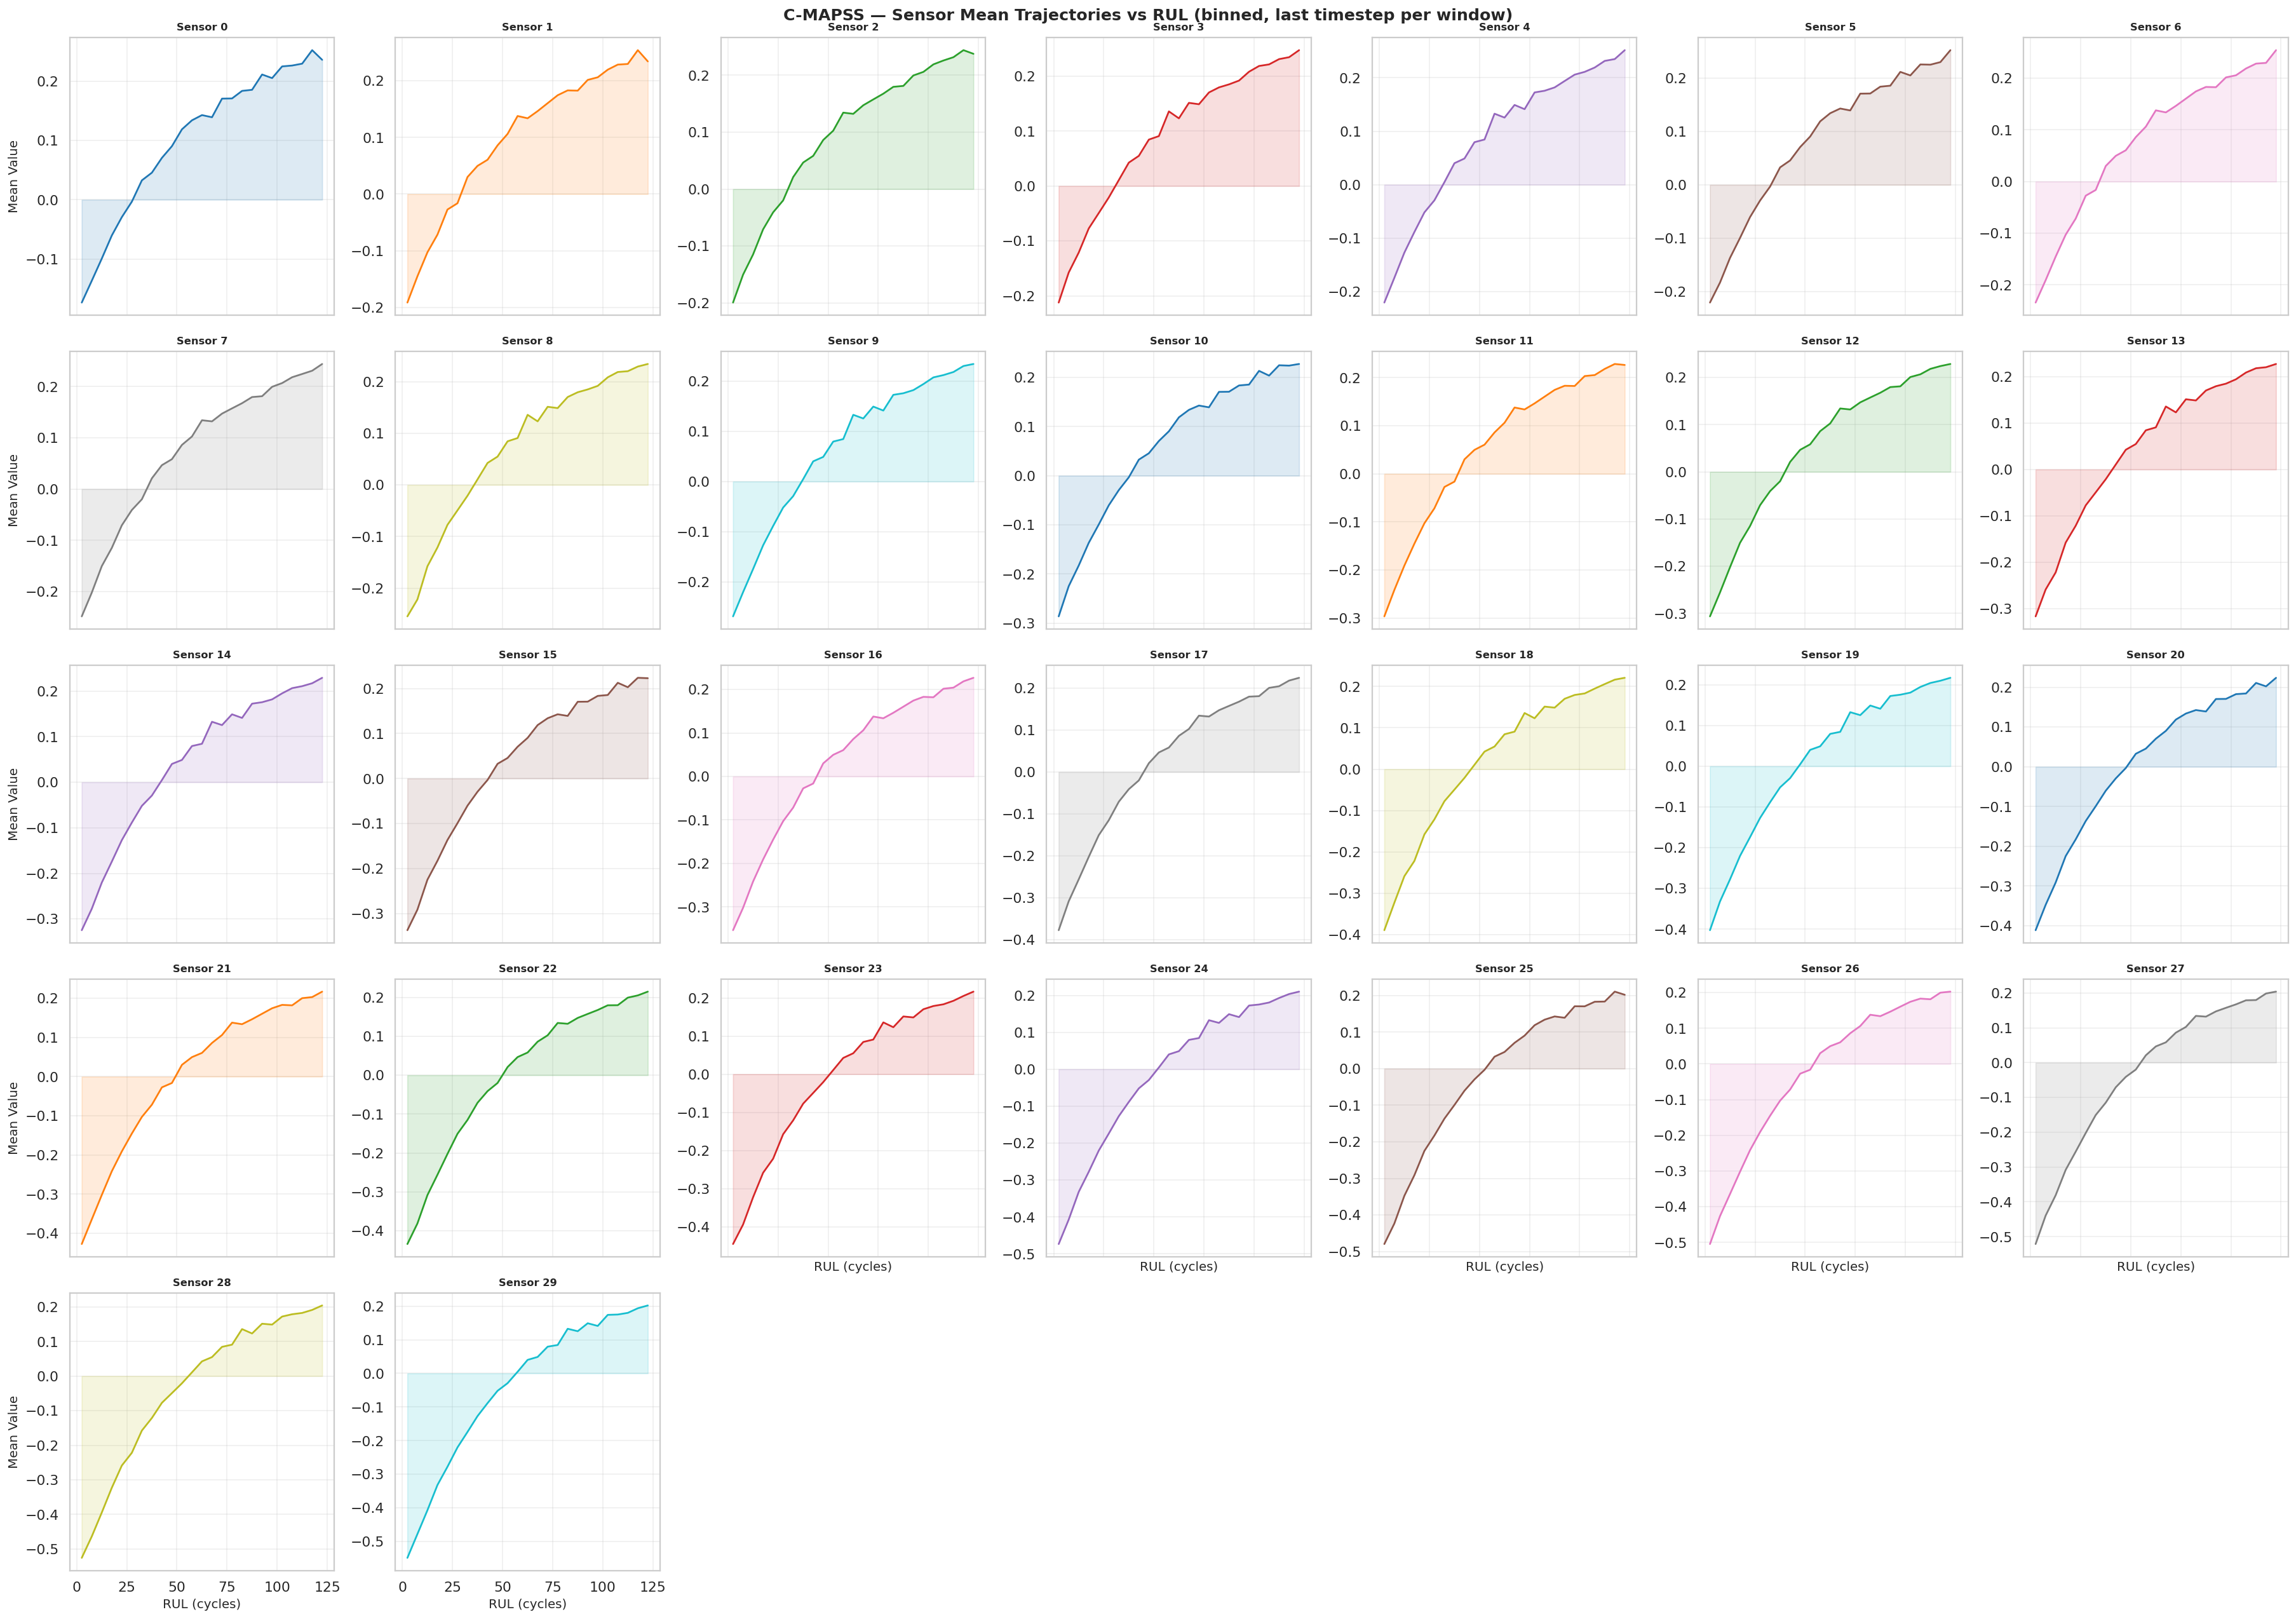

In [8]:
## ── 8.2  C-MAPSS — Sensor Degradation Trajectories ──────────────────────────
# Show how each sensor evolves as a function of RUL. Sensors with strong monotonic
# trends are the most informative for RUL prediction.

if "CMAPSS" in rul_data:
    n_s = cmapss_X.shape[2]  # use local var to avoid stale n_sensors

    sort_idx = np.argsort(cmapss_y)
    sorted_rul = cmapss_y[sort_idx]

    rul_bins_fine = np.arange(0, int(cmapss_y.max()) + 1, 5)
    sensor_trends = np.zeros((len(rul_bins_fine) - 1, n_s))
    for i in range(len(rul_bins_fine) - 1):
        mask = (cmapss_y >= rul_bins_fine[i]) & (cmapss_y < rul_bins_fine[i+1])
        if mask.sum() > 0:
            sensor_trends[i] = cmapss_X[mask, -1, :].mean(axis=0)
        else:
            sensor_trends[i] = np.nan

    bin_centers = (rul_bins_fine[:-1] + rul_bins_fine[1:]) / 2

    # Dynamic grid based on actual channel count
    ncols = min(7, n_s)
    nrows = int(np.ceil(n_s / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharex=True)
    axes = np.array(axes).flatten()
    for s in range(n_s):
        ax = axes[s]
        valid = ~np.isnan(sensor_trends[:, s])
        ax.plot(bin_centers[valid], sensor_trends[valid, s], linewidth=1.5, color=COLORS[s % 10])
        ax.fill_between(bin_centers[valid], sensor_trends[valid, s], alpha=0.15, color=COLORS[s % 10])
        ax.set_title(f"Sensor {s}", fontsize=9, fontweight='bold')
        ax.invert_xaxis()
        if s >= n_s - ncols:
            ax.set_xlabel("RUL (cycles)")
        if s % ncols == 0:
            ax.set_ylabel("Mean Value")
        ax.grid(True, alpha=0.3)
    for s in range(n_s, len(axes)):
        axes[s].set_visible(False)

    fig.suptitle("C-MAPSS — Sensor Mean Trajectories vs RUL (binned, last timestep per window)",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ CMAPSS not loaded")

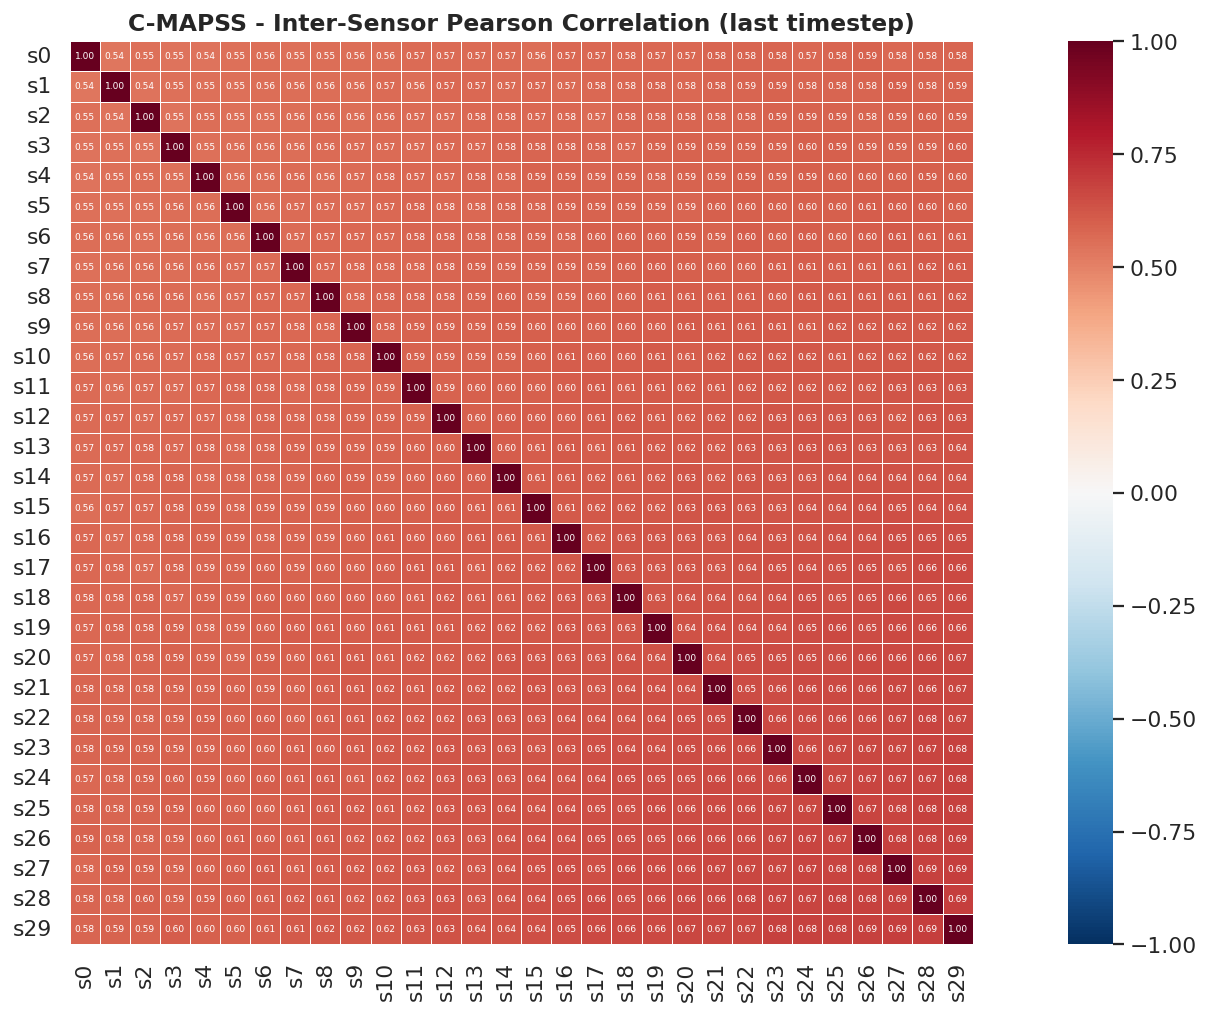

Top 5 most correlated sensor pairs:
 s28-s29: |r| = 0.6925
 s27-s29: |r| = 0.6906
 s27-s28: |r| = 0.6867
 s26-s29: |r| = 0.6867
 s26-s28: |r| = 0.6848

Top 5 least correlated sensor pairs:
 s2-s3: |r| = 0.5468
 s0-s3: |r| = 0.5457
 s0-s4: |r| = 0.5444
 s1-s2: |r| = 0.5426
 s0-s1: |r| = 0.5381


In [16]:
## - 8.3 C-MAPSS - Sensor Correlation Heatmap
# Inter-sensor Pearson correlation. Highly correlated sensors carry redundant info.
# Uncorrelated or anti-correlated sensors are most valuable for the LSTM.

if "CMAPSS" in rul_data:
    # Use last timestep of each window (= most recent reading)
    sensor_last = cmapss_X[:, -1, :]  # (N, n_sensors_local)
    corr_matrix = np.corrcoef(sensor_last.T)
    n_sensors_local = sensor_last.shape[1]

    fig, ax = plt.subplots(figsize=(15, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        annot_kws={"size": 5},  # reduce correlation-value font size
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        xticklabels=[f"s{i}" for i in range(n_sensors_local)],
        yticklabels=[f"s{i}" for i in range(n_sensors_local)],
        ax=ax,
        linewidths=0.5,
        square=True,
    )
    ax.set_title("C-MAPSS - Inter-Sensor Pearson Correlation (last timestep)", fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Identify most and least correlated pairs
    pairs = []
    for i, j in itertools.combinations(range(n_sensors_local), 2):
        pairs.append((f"s{i}-s{j}", abs(corr_matrix[i, j])))
    pairs.sort(key=lambda x: x[1], reverse=True)

    print("Top 5 most correlated sensor pairs:")
    for p, v in pairs[:5]:
        print(f" {p}: |r| = {v:.4f}")

    print("\nTop 5 least correlated sensor pairs:")
    for p, v in pairs[-5:]:
        print(f" {p}: |r| = {v:.4f}")
else:
    print("⚠️ CMAPSS not loaded")

C-MAPSS — Per-Sensor Statistical Profile & Monotonicity Score
Spearman ρ measures monotonic (not necessarily linear) relationship with RUL.
|ρ| > 0.5 = Strong degradation signal · |ρ| < 0.3 = Weak/noisy



Sensor,Mean,Std,Min,Max,Spearman ρ (vs RUL),|ρ|,p-value,Monotonic?
S29,0.0479,0.3072,-1.0000,0.9144,0.6821,0.682059,0.00e+00,✓ Strong
S28,0.0530,0.3040,-0.9855,0.9821,0.6764,0.676358,0.00e+00,✓ Strong
S27,0.0577,0.3011,-0.9855,0.9821,0.6703,0.670348,0.00e+00,✓ Strong
S26,0.0623,0.2984,-0.9855,0.9821,0.6645,0.664465,0.00e+00,✓ Strong
S25,0.0669,0.2956,-0.9855,0.9821,0.6580,0.658034,0.00e+00,✓ Strong
S24,0.0713,0.2931,-0.9855,0.9821,0.6515,0.651545,0.00e+00,✓ Strong
S23,0.0760,0.2899,-0.9855,0.9821,0.6455,0.645467,0.00e+00,✓ Strong
S22,0.0804,0.2876,-0.9855,0.9821,0.6400,0.639957,0.00e+00,✓ Strong
S21,0.0844,0.2856,-0.9855,0.9821,0.6334,0.633401,0.00e+00,✓ Strong
S20,0.0888,0.2829,-0.9855,0.9821,0.6273,0.627326,0.00e+00,✓ Strong


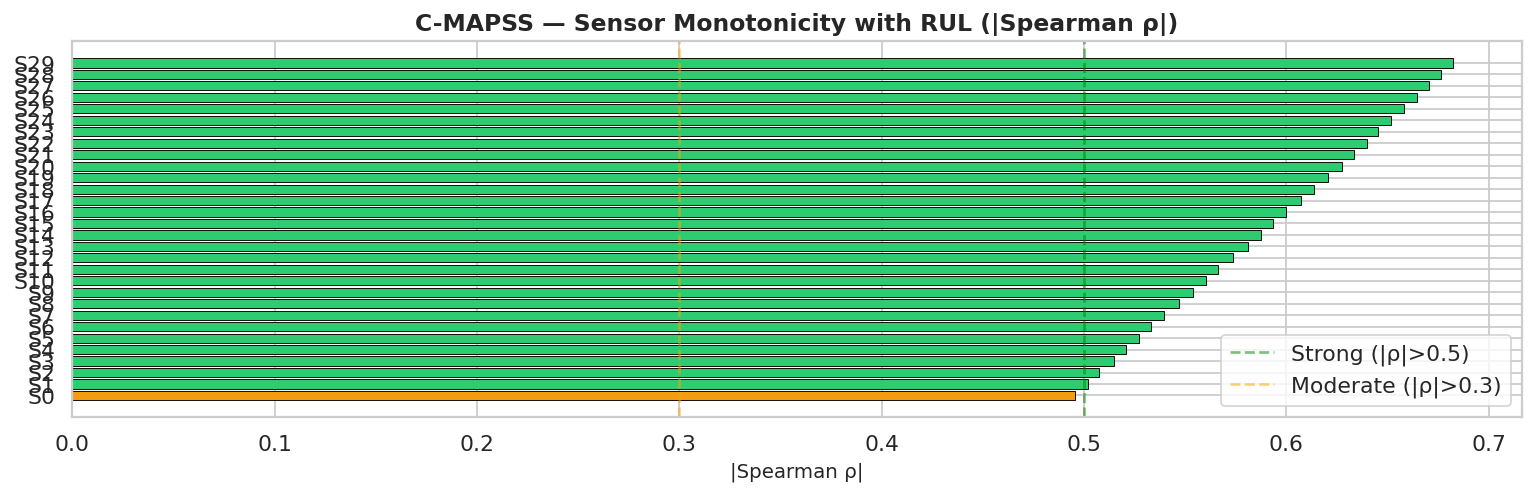

In [17]:
## ── 8.4  C-MAPSS — Per-Sensor Statistical Profiles & Monotonicity Score ──────
# For each sensor, compute Spearman rank correlation with RUL.
# |ρ| close to 1 → strong monotonic degradation trend → good for prediction.
# Also compute mean ± std per sensor for a general profile.

if "CMAPSS" in rul_data:
    from scipy.stats import spearmanr

    sensor_profile_rows = []
    for s in range(n_sensors):
        vals = cmapss_X[:, -1, s]  # last timestep per window
        rho, pval = spearmanr(vals, cmapss_y)
        sensor_profile_rows.append({
            "Sensor": f"S{s}",
            "Mean": f"{vals.mean():.4f}",
            "Std": f"{vals.std():.4f}",
            "Min": f"{vals.min():.4f}",
            "Max": f"{vals.max():.4f}",
            "Spearman ρ (vs RUL)": f"{rho:.4f}",
            "|ρ|": abs(rho),
            "p-value": f"{pval:.2e}",
            "Monotonic?": "✓ Strong" if abs(rho) > 0.5 else ("~ Moderate" if abs(rho) > 0.3 else "✗ Weak"),
        })

    sensor_df = pd.DataFrame(sensor_profile_rows).sort_values("|ρ|", ascending=False)
    print("C-MAPSS — Per-Sensor Statistical Profile & Monotonicity Score")
    print("=" * 110)
    print("Spearman ρ measures monotonic (not necessarily linear) relationship with RUL.")
    print("|ρ| > 0.5 = Strong degradation signal · |ρ| < 0.3 = Weak/noisy\n")
    display(sensor_df.style.hide(axis='index').background_gradient(subset=["|ρ|"], cmap="RdYlGn_r"))

    # Bar chart of |ρ| per sensor
    fig, ax = plt.subplots(figsize=(12, 4))
    colors_mono = ['#2ecc71' if v > 0.5 else '#f39c12' if v > 0.3 else '#e74c3c'
                   for v in sensor_df["|ρ|"]]
    ax.barh(sensor_df["Sensor"], sensor_df["|ρ|"], color=colors_mono, edgecolor='black', linewidth=0.5)
    ax.axvline(0.5, color='green', linestyle='--', alpha=0.5, label='Strong (|ρ|>0.5)')
    ax.axvline(0.3, color='orange', linestyle='--', alpha=0.5, label='Moderate (|ρ|>0.3)')
    ax.set_xlabel("|Spearman ρ|")
    ax.set_title("C-MAPSS — Sensor Monotonicity with RUL (|Spearman ρ|)", fontweight='bold')
    ax.legend(loc='lower right')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ CMAPSS not loaded")

# N-CMAPSS Engine RUL Dataset: In-Depth Analysis

> **Task:** Remaining Useful Life (RUL) regression for turbofan engines.
> **Source:** NASA Prognostics Center of Excellence — N-CMAPSS sub-dataset.
> **Features:** 26 sensor channels per time step · Window = 30 cycles · max_rul = 125 (piece-wise linear degradation).

### What to look for:
- **RUL distribution** — Is it uniform, skewed, or dominated by near-failure samples (low RUL)?
- **Sensor degradation trajectories** — Which sensors show clear monotonic trends as engines approach failure?
- **Sensor correlation** — Co-evolving sensors may be redundant; uncorrelated sensors add complementary information.
- **Health index curvature** — The piece-wise linear model clips RUL at 125 cycles; look for a flat → declining pattern.
- **Operational regime effects** — Different flight conditions modulate sensor readings, adding noise to the degradation signal.


In [ ]:
## ── 9.1  N-CMAPSS — Dataset Overview & RUL Distribution ─────────────────────

if "N-CMAPSS" in rul_data:
    nc_X = rul_data["N-CMAPSS"]["features"]
    nc_y = rul_data["N-CMAPSS"]["targets"]
    nc_n, nc_win, nc_ch = nc_X.shape

    print("N-CMAPSS — Dataset Shape Summary")
    print("=" * 60)
    print(f"  Samples (windows):    {nc_n:,}")
    print(f"  Window length:        {nc_win} time steps")
    print(f"  Sensor channels:      {nc_ch}")
    print(f"  RUL range:            [{nc_y.min():.0f}, {nc_y.max():.0f}]")
    print(f"  RUL mean ± std:       {nc_y.mean():.1f} ± {nc_y.std():.1f}")
    print(f"  RUL median:           {np.median(nc_y):.1f}")

    nc_summary = pd.DataFrame({
        "Metric": ["Samples", "Window", "Channels", "RUL Min", "RUL Max",
                    "RUL Mean", "RUL Std", "RUL Median", "RUL Q25", "RUL Q75"],
        "Value": [nc_n, nc_win, nc_ch, nc_y.min(), nc_y.max(),
                  f"{nc_y.mean():.2f}", f"{nc_y.std():.2f}", np.median(nc_y),
                  np.percentile(nc_y, 25), np.percentile(nc_y, 75)]
    })
    display(nc_summary.style.hide(axis='index'))

    # ── RUL Distribution: histogram, KDE, box ──
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].hist(nc_y, bins=60, color='#8e44ad', edgecolor='black', linewidth=0.5, alpha=0.85)
    axes[0].axvline(nc_y.mean(), color='red', linestyle='--', label=f'Mean={nc_y.mean():.1f}')
    axes[0].axvline(np.median(nc_y), color='orange', linestyle='--', label=f'Median={np.median(nc_y):.1f}')
    axes[0].set_title("N-CMAPSS — RUL Histogram", fontweight='bold')
    axes[0].set_xlabel("RUL"); axes[0].set_ylabel("Count"); axes[0].legend()

    sns.kdeplot(nc_y, ax=axes[1], fill=True, color='#8e44ad', alpha=0.5)
    axes[1].set_title("N-CMAPSS — RUL KDE", fontweight='bold')
    axes[1].set_xlabel("RUL")

    axes[2].boxplot(nc_y, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#8e44ad', alpha=0.5))
    axes[2].set_title("N-CMAPSS — RUL Box Plot", fontweight='bold')
    axes[2].set_ylabel("RUL")
    plt.tight_layout()
    plt.show()

    # ── RUL Binned Distribution ──
    nc_max = int(nc_y.max())
    nc_bin_edges = list(range(0, nc_max + 50, 50)) + [nc_max + 1]
    nc_bin_labels = [f"{nc_bin_edges[i]}-{nc_bin_edges[i+1]-1}" for i in range(len(nc_bin_edges)-1)]
    nc_binned = pd.cut(nc_y, bins=nc_bin_edges, labels=nc_bin_labels, right=False)
    nc_bin_counts = nc_binned.value_counts().sort_index()
    print("\nN-CMAPSS — RUL Binned Distribution")
    print("=" * 55)
    for b, c in nc_bin_counts.items():
        pct = c / len(nc_y) * 100
        bar = "█" * int(pct)
        print(f"  {b:>12s}:  {c:>6,} samples  ({pct:5.1f}%)  {bar}")
else:
    print("⚠️ N-CMAPSS not loaded — run cell 4.1b first")

In [ ]:
## ── 9.2  N-CMAPSS — Sensor Degradation Trajectories ──────────────────────────
# Same methodology as C-MAPSS §8.2 but adapted for potentially higher channel count.

if "N-CMAPSS" in rul_data:
    rul_bins_nc = np.arange(0, int(nc_y.max()) + 1, max(1, int(nc_y.max()) // 30))
    nc_trends = np.full((len(rul_bins_nc) - 1, nc_ch), np.nan)
    for i in range(len(rul_bins_nc) - 1):
        mask = (nc_y >= rul_bins_nc[i]) & (nc_y < rul_bins_nc[i+1])
        if mask.sum() > 0:
            nc_trends[i] = nc_X[mask, -1, :].mean(axis=0)

    bin_ctrs_nc = (rul_bins_nc[:-1] + rul_bins_nc[1:]) / 2

    # Dynamic grid: max 8 columns
    ncols = min(8, nc_ch)
    nrows = int(np.ceil(nc_ch / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True)
    axes = np.array(axes).flatten()
    for s in range(nc_ch):
        ax = axes[s]
        valid = ~np.isnan(nc_trends[:, s])
        ax.plot(bin_ctrs_nc[valid], nc_trends[valid, s], linewidth=1.2, color=COLORS[s % 10])
        ax.fill_between(bin_ctrs_nc[valid], nc_trends[valid, s], alpha=0.1, color=COLORS[s % 10])
        ax.set_title(f"Ch {s}", fontsize=8, fontweight='bold')
        ax.invert_xaxis()
        ax.grid(True, alpha=0.2)
        if s >= nc_ch - ncols:
            ax.set_xlabel("RUL")
    # Hide unused axes
    for s in range(nc_ch, len(axes)):
        axes[s].set_visible(False)
    fig.suptitle("N-CMAPSS — Per-Channel Mean Trajectory vs RUL", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ N-CMAPSS not loaded")

In [ ]:
## ── 9.3  N-CMAPSS — Sensor Correlation Heatmap ───────────────────────────────

if "N-CMAPSS" in rul_data:
    nc_last = nc_X[:, -1, :]  # (N, ch)
    nc_corr = np.corrcoef(nc_last.T)

    fig, ax = plt.subplots(figsize=(max(8, nc_ch * 0.6), max(7, nc_ch * 0.5)))
    sns.heatmap(nc_corr, cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, linewidths=0.3,
                xticklabels=[f"Ch{i}" for i in range(nc_ch)],
                yticklabels=[f"Ch{i}" for i in range(nc_ch)],
                annot=nc_ch <= 20, fmt=".1f" if nc_ch <= 20 else "", square=True)
    ax.set_title("N-CMAPSS — Inter-Channel Pearson Correlation (last timestep)", fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Identify high/low correlation pairs
    import itertools as it
    nc_pairs = [(f"Ch{i}-Ch{j}", abs(nc_corr[i,j]))
                for i, j in it.combinations(range(nc_ch), 2)]
    nc_pairs.sort(key=lambda x: x[1], reverse=True)
    print("Top 5 most correlated channel pairs:")
    for p, v in nc_pairs[:5]:
        print(f"  {p}: |r| = {v:.4f}")
    print(f"\nTop 5 least correlated:")
    for p, v in nc_pairs[-5:]:
        print(f"  {p}: |r| = {v:.4f}")
else:
    print("⚠️ N-CMAPSS not loaded")

In [ ]:
## ── 9.4  N-CMAPSS — Per-Channel Monotonicity & Statistical Profile ────────────

if "N-CMAPSS" in rul_data:
    from scipy.stats import spearmanr

    nc_prof_rows = []
    for s in range(nc_ch):
        vals = nc_X[:, -1, s]
        rho, pval = spearmanr(vals, nc_y)
        nc_prof_rows.append({
            "Channel": f"Ch{s}",
            "Mean": f"{vals.mean():.4f}",
            "Std": f"{vals.std():.4f}",
            "Min": f"{vals.min():.4f}",
            "Max": f"{vals.max():.4f}",
            "Spearman ρ": f"{rho:.4f}",
            "|ρ|": abs(rho),
            "p-value": f"{pval:.2e}",
            "Signal": "✓ Strong" if abs(rho) > 0.5 else ("~ Moderate" if abs(rho) > 0.3 else "✗ Weak"),
        })

    nc_prof_df = pd.DataFrame(nc_prof_rows).sort_values("|ρ|", ascending=False)
    print("N-CMAPSS — Per-Channel Monotonicity with RUL")
    print("=" * 100)
    display(nc_prof_df.style.hide(axis='index').background_gradient(subset=["|ρ|"], cmap="RdYlGn_r"))

    # Horizontal bar chart
    fig, ax = plt.subplots(figsize=(12, max(4, nc_ch * 0.25)))
    bar_colors = ['#2ecc71' if v > 0.5 else '#f39c12' if v > 0.3 else '#e74c3c'
                  for v in nc_prof_df["|ρ|"]]
    ax.barh(nc_prof_df["Channel"], nc_prof_df["|ρ|"], color=bar_colors, edgecolor='black', linewidth=0.4)
    ax.axvline(0.5, color='green', linestyle='--', alpha=0.5, label='|ρ|>0.5 Strong')
    ax.axvline(0.3, color='orange', linestyle='--', alpha=0.5, label='|ρ|>0.3 Moderate')
    ax.set_xlabel("|Spearman ρ|")
    ax.set_title("N-CMAPSS — Channel Monotonicity with RUL", fontweight='bold')
    ax.legend(loc='lower right')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ N-CMAPSS not loaded")

---
---
# 10 — FEMTO Bearing RUL Dataset (PRONOSTIA): In-Depth Analysis
> **Task:** Remaining Useful Life (RUL) regression for bearings under accelerated degradation.
> **Source:** FEMTO-ST / PRONOSTIA platform (IEEE PHM 2012 Challenge).
> **Signal:** Vibration accelerometer @ 25.6 kHz · Window = 2048 · FD1 operating condition.

### What to look for:
- **RUL distribution** — Accelerated tests yield shorter lifetimes; expect a right-skewed distribution.
- **Vibration amplitude growth** — As bearing damage progresses, vibration energy increases non-linearly.
- **Channel informativeness** — Some vibration axes may carry more prognostic value than others.
- **Degradation onset** — In early life the signal is stable (health index flat), then transitions to rapid degradation.
- **Sample scarcity** — FEMTO datasets are typically small (thousands of windows, not millions). This makes synthetic augmentation critical.

FEMTO (PRONOSTIA) — Dataset Shape Summary
  Samples (windows):    3,674
  Window length:        2
  Channels:             2048
  RUL range:            [1, 2803]
  RUL mean ± std:       1173.0 ± 826.6
  RUL median:           966.5


Metric,Value
Samples,3674
Window,2
Channels,2048
RUL Min,1.000000
RUL Max,2803.000000
RUL Mean,1172.99
RUL Std,826.61
RUL Median,966.500000
RUL Q25,460.000000
RUL Q75,1884.750000


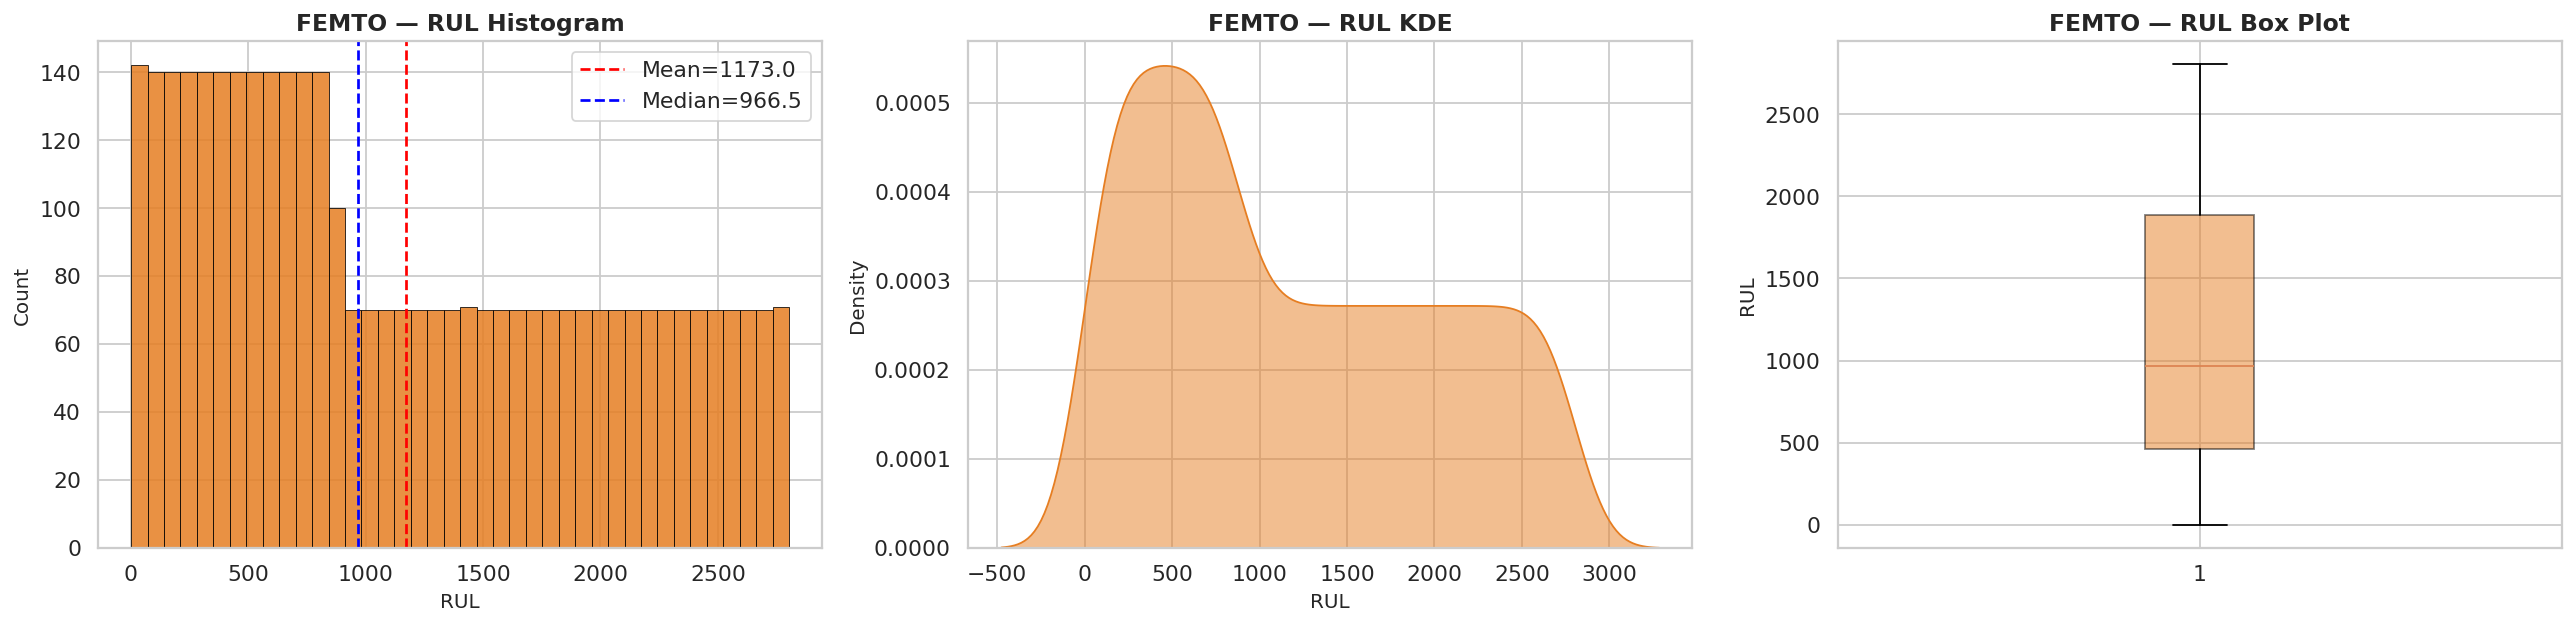

ValueError: bins must increase monotonically.

In [ ]:
## ── 10.1  FEMTO — Dataset Overview & RUL Distribution ────────────────────────

if "FEMTO" in rul_data:
    femto_X = rul_data["FEMTO"]["features"]
    femto_y = rul_data["FEMTO"]["targets"]
    fm_n = femto_X.shape[0]

    # Handle both layouts: (N, window, channels) and (N, channels, window)
    if femto_X.ndim == 3:
        if femto_X.shape[1] <= 16 and femto_X.shape[2] > femto_X.shape[1]:
            fm_ch = femto_X.shape[1]
            fm_win = femto_X.shape[2]
        else:
            fm_win = femto_X.shape[1]
            fm_ch = femto_X.shape[2]
    else:
        fm_win = femto_X.shape[1]
        fm_ch = 1

    print("FEMTO (PRONOSTIA) — Dataset Shape Summary")
    print("=" * 60)
    print(f"  Samples (windows):    {fm_n:,}")
    print(f"  Window length:        {fm_win}")
    print(f"  Channels:             {fm_ch}")
    print(f"  RUL range:            [{femto_y.min():.0f}, {femto_y.max():.0f}]")
    print(f"  RUL mean ± std:       {femto_y.mean():.1f} ± {femto_y.std():.1f}")
    print(f"  RUL median:           {np.median(femto_y):.1f}")

    femto_summary = pd.DataFrame({
        "Metric": ["Samples", "Window", "Channels", "RUL Min", "RUL Max",
                    "RUL Mean", "RUL Std", "RUL Median", "RUL Q25", "RUL Q75"],
        "Value": [fm_n, fm_win, fm_ch, femto_y.min(), femto_y.max(),
                  f"{femto_y.mean():.2f}", f"{femto_y.std():.2f}", np.median(femto_y),
                  np.percentile(femto_y, 25), np.percentile(femto_y, 75)]
    })
    display(femto_summary.style.hide(axis='index'))

    # ── RUL Distribution ──
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].hist(femto_y, bins=40, color='#e67e22', edgecolor='black', linewidth=0.5, alpha=0.85)
    axes[0].axvline(femto_y.mean(), color='red', linestyle='--', label=f'Mean={femto_y.mean():.1f}')
    axes[0].axvline(np.median(femto_y), color='blue', linestyle='--', label=f'Median={np.median(femto_y):.1f}')
    axes[0].set_title("FEMTO — RUL Histogram", fontweight='bold')
    axes[0].set_xlabel("RUL"); axes[0].set_ylabel("Count"); axes[0].legend()

    sns.kdeplot(femto_y, ax=axes[1], fill=True, color='#e67e22', alpha=0.5)
    # ── Binned RUL ──
    fm_max = int(femto_y.max())
    fm_bin_step = max(1, fm_max // 8)

    # Build strictly increasing bin edges (required by pd.cut)
    fm_bin_edges = list(range(0, fm_max + 1, fm_bin_step))
    if fm_bin_edges[-1] <= fm_max:
        fm_bin_edges.append(fm_max + 1)

    fm_bin_labels = [f"{fm_bin_edges[i]}-{fm_bin_edges[i+1]-1}" for i in range(len(fm_bin_edges)-1)]
    fm_binned = pd.cut(femto_y, bins=fm_bin_edges, labels=fm_bin_labels, right=False)
    axes[2].set_ylabel("RUL")
    plt.tight_layout()
    plt.show()

    # ── Binned RUL ──
    fm_max = int(femto_y.max())
    fm_bin_step = max(1, fm_max // 8)
    fm_bin_edges = list(range(0, fm_max + fm_bin_step, fm_bin_step)) + [fm_max + 1]
    fm_bin_labels = [f"{fm_bin_edges[i]}-{fm_bin_edges[i+1]-1}" for i in range(len(fm_bin_edges)-1)]
    fm_binned = pd.cut(femto_y, bins=fm_bin_edges, labels=fm_bin_labels, right=False)
    fm_bin_counts = fm_binned.value_counts().sort_index()
    print("\nFEMTO — RUL Binned Distribution")
    print("=" * 55)
    for b, c in fm_bin_counts.items():
        pct = c / len(femto_y) * 100
        bar = "█" * int(pct)
        print(f"  {b:>12s}:  {c:>5,} samples  ({pct:5.1f}%)  {bar}")
else:
    print("⚠️ FEMTO not loaded — run cell 4.1 first")

In [ ]:
## ── 10.2  FEMTO — Channel Degradation Trajectories ───────────────────────────

if "FEMTO" in rul_data:
    fm_bins = np.arange(0, int(femto_y.max()) + 1, max(1, int(femto_y.max()) // 25))
    fm_trends = np.full((len(fm_bins) - 1, fm_ch), np.nan)
    for i in range(len(fm_bins) - 1):
        mask = (femto_y >= fm_bins[i]) & (femto_y < fm_bins[i+1])
        if mask.sum() > 0:
            fm_trends[i] = femto_X[mask, -1, :].mean(axis=0)
    fm_ctrs = (fm_bins[:-1] + fm_bins[1:]) / 2

    ncols_fm = min(4, fm_ch)
    nrows_fm = int(np.ceil(fm_ch / ncols_fm))
    fig, axes = plt.subplots(nrows_fm, ncols_fm, figsize=(5 * ncols_fm, 4 * nrows_fm), sharex=True)
    axes = np.array(axes).flatten() if fm_ch > 1 else [axes]
    for s in range(fm_ch):
        ax = axes[s]
        valid = ~np.isnan(fm_trends[:, s])
        ax.plot(fm_ctrs[valid], fm_trends[valid, s], linewidth=1.5, color=COLORS[s % 10])
        ax.fill_between(fm_ctrs[valid], fm_trends[valid, s], alpha=0.15, color=COLORS[s % 10])
        ax.set_title(f"Channel {s}", fontweight='bold')
        ax.invert_xaxis()
        ax.set_xlabel("RUL")
        ax.set_ylabel("Mean Value")
        ax.grid(True, alpha=0.3)
    for s in range(fm_ch, len(axes)):
        axes[s].set_visible(False)
    fig.suptitle("FEMTO — Per-Channel Mean Trajectory vs RUL", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ FEMTO not loaded")

In [ ]:
## ── 10.3  FEMTO — Sensor Correlation & Monotonicity ──────────────────────────

if "FEMTO" in rul_data and fm_ch > 1:
    # Correlation heatmap
    fm_last = femto_X[:, -1, :]
    fm_corr = np.corrcoef(fm_last.T)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.heatmap(fm_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
                xticklabels=[f"Ch{i}" for i in range(fm_ch)],
                yticklabels=[f"Ch{i}" for i in range(fm_ch)],
                ax=axes[0], linewidths=0.5, square=True)
    axes[0].set_title("FEMTO — Inter-Channel Correlation", fontweight='bold')

    # Monotonicity bars
    from scipy.stats import spearmanr
    fm_rhos = []
    for s in range(fm_ch):
        rho, _ = spearmanr(femto_X[:, -1, s], femto_y)
        fm_rhos.append(abs(rho))
    bar_colors = ['#2ecc71' if v > 0.5 else '#f39c12' if v > 0.3 else '#e74c3c' for v in fm_rhos]
    axes[1].barh([f"Ch{s}" for s in range(fm_ch)], fm_rhos, color=bar_colors, edgecolor='black', linewidth=0.5)
    axes[1].axvline(0.5, color='green', linestyle='--', alpha=0.5)
    axes[1].axvline(0.3, color='orange', linestyle='--', alpha=0.5)
    axes[1].set_xlabel("|Spearman ρ|")
    axes[1].set_title("FEMTO — Channel Monotonicity with RUL", fontweight='bold')
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.show()

elif "FEMTO" in rul_data and fm_ch == 1:
    from scipy.stats import spearmanr
    rho, pval = spearmanr(femto_X[:, -1, 0], femto_y)
    print(f"FEMTO — Single-channel monotonicity:  Spearman ρ = {rho:.4f}  (p = {pval:.2e})")
    print(f"  Interpretation: {'Strong' if abs(rho)>0.5 else 'Moderate' if abs(rho)>0.3 else 'Weak'} "
          f"monotonic relationship with RUL")
else:
    print("⚠️ FEMTO not loaded")

---
---
# 11 — XJTU-SY Bearing RUL Dataset: In-Depth Analysis
> **Task:** Remaining Useful Life (RUL) regression for bearings.
> **Source:** Xi'an Jiaotong University & SY Bearing Company — accelerated lifetime tests.
> **Signal:** Vibration (horizontal + vertical accelerometers) @ 25.6 kHz · Window = 2048 · FD1 condition.

### What to look for:
- **RUL distribution** — Does the dataset favour near-failure windows (low RUL) or early-life windows (high RUL)?
- **Multi-channel dynamics** — Horizontal vs vertical channels may degrade at different rates.
- **Comparison with FEMTO** — Both are bearing RUL datasets at the same sampling rate; subtle differences in degradation profiles may affect transfer learning.
- **Impulsive behaviour** — Real bearing failures produce impulse-train signatures that grow in amplitude as damage progresses.
- **Viability for augmentation** — If the dataset is small, FlowMatch-PdM synthetic generation becomes especially valuable.

In [ ]:
## ── 11.1  XJTU-SY — Dataset Overview & RUL Distribution ─────────────────────

if "XJTU-SY" in rul_data:
    xjtu_X = rul_data["XJTU-SY"]["features"]
    xjtu_y = rul_data["XJTU-SY"]["targets"]
    xj_n = xjtu_X.shape[0]
    xj_win = xjtu_X.shape[1]
    xj_ch = xjtu_X.shape[2] if xjtu_X.ndim == 3 else 1

    print("XJTU-SY — Dataset Shape Summary")
    print("=" * 60)
    print(f"  Samples (windows):    {xj_n:,}")
    print(f"  Window length:        {xj_win}")
    print(f"  Channels:             {xj_ch}")
    print(f"  RUL range:            [{xjtu_y.min():.0f}, {xjtu_y.max():.0f}]")
    print(f"  RUL mean ± std:       {xjtu_y.mean():.1f} ± {xjtu_y.std():.1f}")
    print(f"  RUL median:           {np.median(xjtu_y):.1f}")

    xjtu_summary = pd.DataFrame({
        "Metric": ["Samples", "Window", "Channels", "RUL Min", "RUL Max",
                    "RUL Mean", "RUL Std", "RUL Median", "RUL Q25", "RUL Q75"],
        "Value": [xj_n, xj_win, xj_ch, xjtu_y.min(), xjtu_y.max(),
                  f"{xjtu_y.mean():.2f}", f"{xjtu_y.std():.2f}", np.median(xjtu_y),
                  np.percentile(xjtu_y, 25), np.percentile(xjtu_y, 75)]
    })
    display(xjtu_summary.style.hide(axis='index'))

    # ── RUL Distribution ──
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    axes[0].hist(xjtu_y, bins=40, color='#c0392b', edgecolor='black', linewidth=0.5, alpha=0.85)
    axes[0].axvline(xjtu_y.mean(), color='blue', linestyle='--', label=f'Mean={xjtu_y.mean():.1f}')
    axes[0].axvline(np.median(xjtu_y), color='green', linestyle='--', label=f'Median={np.median(xjtu_y):.1f}')
    axes[0].set_title("XJTU-SY — RUL Histogram", fontweight='bold')
    axes[0].set_xlabel("RUL"); axes[0].set_ylabel("Count"); axes[0].legend()

    sns.kdeplot(xjtu_y, ax=axes[1], fill=True, color='#c0392b', alpha=0.5)
    axes[1].set_title("XJTU-SY — RUL KDE", fontweight='bold')
    axes[1].set_xlabel("RUL")

    axes[2].boxplot(xjtu_y, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#c0392b', alpha=0.5))
    axes[2].set_title("XJTU-SY — RUL Box Plot", fontweight='bold')
    axes[2].set_ylabel("RUL")
    plt.tight_layout()
    plt.show()

    # ── Binned RUL ──
    xj_max = int(xjtu_y.max())
    xj_bin_step = max(1, xj_max // 8)
    xj_bin_edges = list(range(0, xj_max + xj_bin_step, xj_bin_step)) + [xj_max + 1]
    xj_bin_labels = [f"{xj_bin_edges[i]}-{xj_bin_edges[i+1]-1}" for i in range(len(xj_bin_edges)-1)]
    xj_binned = pd.cut(xjtu_y, bins=xj_bin_edges, labels=xj_bin_labels, right=False)
    xj_bin_counts = xj_binned.value_counts().sort_index()
    print("\nXJTU-SY — RUL Binned Distribution")
    print("=" * 55)
    for b, c in xj_bin_counts.items():
        pct = c / len(xjtu_y) * 100
        bar = "█" * int(pct)
        print(f"  {b:>12s}:  {c:>5,} samples  ({pct:5.1f}%)  {bar}")
else:
    print("⚠️ XJTU-SY not loaded — run cell 4.1 first")

In [ ]:
## ── 11.2  XJTU-SY — Channel Degradation Trajectories ─────────────────────────

if "XJTU-SY" in rul_data:
    xj_bins = np.arange(0, int(xjtu_y.max()) + 1, max(1, int(xjtu_y.max()) // 25))
    xj_trends = np.full((len(xj_bins) - 1, xj_ch), np.nan)
    for i in range(len(xj_bins) - 1):
        mask = (xjtu_y >= xj_bins[i]) & (xjtu_y < xj_bins[i+1])
        if mask.sum() > 0:
            xj_trends[i] = xjtu_X[mask, -1, :].mean(axis=0)
    xj_ctrs = (xj_bins[:-1] + xj_bins[1:]) / 2

    ncols_xj = min(4, xj_ch)
    nrows_xj = int(np.ceil(xj_ch / ncols_xj))
    fig, axes = plt.subplots(nrows_xj, ncols_xj, figsize=(5 * ncols_xj, 4 * nrows_xj), sharex=True)
    axes = np.array(axes).flatten() if xj_ch > 1 else [axes]
    ch_names_xj = [f"Horizontal (Ch{i})" if i == 0 else f"Vertical (Ch{i})" if i == 1 else f"Ch{i}"
                   for i in range(xj_ch)]
    for s in range(xj_ch):
        ax = axes[s]
        valid = ~np.isnan(xj_trends[:, s])
        ax.plot(xj_ctrs[valid], xj_trends[valid, s], linewidth=1.5, color=COLORS[s % 10])
        ax.fill_between(xj_ctrs[valid], xj_trends[valid, s], alpha=0.15, color=COLORS[s % 10])
        ax.set_title(ch_names_xj[s], fontweight='bold')
        ax.invert_xaxis()
        ax.set_xlabel("RUL")
        ax.set_ylabel("Mean Value")
        ax.grid(True, alpha=0.3)
    for s in range(xj_ch, len(axes)):
        axes[s].set_visible(False)
    fig.suptitle("XJTU-SY — Per-Channel Mean Trajectory vs RUL", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ XJTU-SY not loaded")

In [ ]:
## ── 11.3  XJTU-SY — Sensor Correlation & Monotonicity ────────────────────────

if "XJTU-SY" in rul_data and xj_ch > 1:
    from scipy.stats import spearmanr

    xj_last = xjtu_X[:, -1, :]
    xj_corr = np.corrcoef(xj_last.T)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    sns.heatmap(xj_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
                xticklabels=ch_names_xj, yticklabels=ch_names_xj,
                ax=axes[0], linewidths=0.5, square=True)
    axes[0].set_title("XJTU-SY — Inter-Channel Correlation", fontweight='bold')

    xj_rhos = []
    for s in range(xj_ch):
        rho, _ = spearmanr(xjtu_X[:, -1, s], xjtu_y)
        xj_rhos.append(abs(rho))
    bar_colors = ['#2ecc71' if v > 0.5 else '#f39c12' if v > 0.3 else '#e74c3c' for v in xj_rhos]
    axes[1].barh(ch_names_xj, xj_rhos, color=bar_colors, edgecolor='black', linewidth=0.5)
    axes[1].axvline(0.5, color='green', linestyle='--', alpha=0.5)
    axes[1].axvline(0.3, color='orange', linestyle='--', alpha=0.5)
    axes[1].set_xlabel("|Spearman ρ|")
    axes[1].set_title("XJTU-SY — Channel Monotonicity with RUL", fontweight='bold')
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.show()

elif "XJTU-SY" in rul_data and xj_ch == 1:
    from scipy.stats import spearmanr
    rho, pval = spearmanr(xjtu_X[:, -1, 0], xjtu_y)
    print(f"XJTU-SY — Single-channel monotonicity:  Spearman ρ = {rho:.4f}  (p = {pval:.2e})")
else:
    print("⚠️ XJTU-SY not loaded")

---
---
# 12 — Cross-Dataset Comparative Analysis
> Side-by-side comparison of all 6 datasets across multiple axes:
> **Scale**, **Dimensionality**, **Imbalance Severity**, **Signal Characteristics**, **Augmentation Viability**.
> 
> This section synthesises the per-dataset findings into actionable insights for FlowMatch-PdM model design, training strategy, and expected performance bottlenecks.

In [ ]:
## ── 12.1  Cross-Dataset Scale Comparison (Log-Scale Bar Chart) ────────────────
# Compare total sample counts across all 6 datasets on a log scale.
# This directly highlights which datasets are data-rich vs data-scarce —
# critical for deciding where synthetic augmentation is most needed.

ds_names = ["CWRU", "Paderborn"]
ds_sizes = [sum(cwru_splits.values()), sum(pb_splits.values())]

for name in ["CMAPSS", "N-CMAPSS", "FEMTO", "XJTU-SY"]:
    if name in rul_data:
        ds_names.append(name)
        ds_sizes.append(rul_data[name]["features"].shape[0])

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors_ds = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad', '#e67e22', '#c0392b']
bars = ax.barh(ds_names, ds_sizes, color=bar_colors_ds[:len(ds_names)], edgecolor='black', linewidth=0.5)
ax.set_xscale('log')
ax.set_xlabel("Total Samples (log scale)")
ax.set_title("Cross-Dataset — Total Sample Count Comparison", fontweight='bold', fontsize=14)
for bar, val in zip(bars, ds_sizes):
    ax.text(bar.get_width() * 1.1, bar.get_y() + bar.get_height()/2,
            f"{val:,.0f}", va='center', fontsize=10, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nKey Insight: Data-scarce datasets (FEMTO, XJTU-SY) benefit most from FlowMatch augmentation.")
print("Data-rich datasets (Paderborn, CWRU) provide stable baselines for method validation.")

In [ ]:
## ── 12.2  Cross-Dataset Dimensionality & Complexity Radar ──────────────────────
# Compare window length, number of channels, and number of classes/target-range
# across all datasets to visualize the "difficulty landscape".

cross_rows = []
cross_rows.append({"Dataset": "CWRU",      "Window":  2048, "Channels": 1,  "Classes/Bins": 10, "Samples": sum(cwru_splits.values()), "Task": "Classification"})
cross_rows.append({"Dataset": "Paderborn", "Window":  4096, "Channels": 1,  "Classes/Bins": 31, "Samples": sum(pb_splits.values()),   "Task": "Classification"})
for name in ["CMAPSS", "N-CMAPSS", "FEMTO", "XJTU-SY"]:
    if name in rul_data:
        f = rul_data[name]["features"]
        t = rul_data[name]["targets"]
        cross_rows.append({
            "Dataset": name,
            "Window": f.shape[1],
            "Channels": f.shape[2] if f.ndim == 3 else 1,
            "Classes/Bins": len(np.unique(np.digitize(t, bins=np.linspace(t.min(), t.max(), 11)))),
            "Samples": f.shape[0],
            "Task": "RUL Regression",
        })

cross_df = pd.DataFrame(cross_rows)
print("Cross-Dataset — Dimensionality & Complexity Summary")
print("=" * 90)
display(cross_df.style.hide(axis='index'))

# Grouped bar chart: Window, Channels, Classes side-by-side (log scale for window)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Window length
axes[0].bar(cross_df["Dataset"], cross_df["Window"], color=bar_colors_ds[:len(cross_df)], edgecolor='black', linewidth=0.5)
axes[0].set_title("Window Length (samples)", fontweight='bold')
axes[0].set_ylabel("Window Length")
axes[0].tick_params(axis='x', rotation=30)
for i, (_, row) in enumerate(cross_df.iterrows()):
    axes[0].text(i, row["Window"] + 50, f"{row['Window']:,}", ha='center', fontsize=8)

# Channels
axes[1].bar(cross_df["Dataset"], cross_df["Channels"], color=bar_colors_ds[:len(cross_df)], edgecolor='black', linewidth=0.5)
axes[1].set_title("Number of Channels", fontweight='bold')
axes[1].set_ylabel("Channels")
axes[1].tick_params(axis='x', rotation=30)
for i, (_, row) in enumerate(cross_df.iterrows()):
    axes[1].text(i, row["Channels"] + 0.2, str(row["Channels"]), ha='center', fontsize=9)

# Classes / RUL bins
axes[2].bar(cross_df["Dataset"], cross_df["Classes/Bins"], color=bar_colors_ds[:len(cross_df)], edgecolor='black', linewidth=0.5)
axes[2].set_title("Classes (classification) / RUL Bins (regression)", fontweight='bold')
axes[2].set_ylabel("Count")
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle("Cross-Dataset — Dimensionality Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
## ── 12.3  RUL Target Distribution Overlay (All 4 RUL Datasets) ────────────────
# Overlay KDE of RUL target values for CMAPSS, N-CMAPSS, FEMTO, XJTU-SY.
# This reveals how differently the degradation trajectories are distributed
# across the benchmark, which directly impacts loss function design.

rul_colors = {"CMAPSS": "steelblue", "N-CMAPSS": "#8e44ad", "FEMTO": "#e67e22", "XJTU-SY": "#c0392b"}

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# KDE overlay
for name, rd in rul_data.items():
    t = rd["targets"]
    # Normalise to [0, 1] for comparable x-axis
    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-12)
    sns.kdeplot(t_norm, ax=axes[0], label=f"{name} (n={len(t):,})", linewidth=1.5,
                color=rul_colors.get(name, 'grey'), fill=True, alpha=0.2)
axes[0].set_title("RUL Target Distribution Overlay (normalised to [0,1])", fontweight='bold')
axes[0].set_xlabel("Normalised RUL")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

# Violin plot with raw RUL (separate y-scale per dataset via normalisation)
rul_violin_rows = []
for name, rd in rul_data.items():
    t = rd["targets"]
    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-12)
    for val in t_norm[::max(1, len(t_norm)//500)]:  # subsample for speed
        rul_violin_rows.append({"Dataset": name, "Normalised RUL": val})
rul_violin_df = pd.DataFrame(rul_violin_rows)
sns.violinplot(data=rul_violin_df, x="Dataset", y="Normalised RUL", ax=axes[1],
               palette=rul_colors, inner="quartile", cut=0)
axes[1].set_title("RUL Violin Plots (normalised)", fontweight='bold')

plt.tight_layout()
plt.show()

# Print skewness and kurtosis for each RUL dataset
print("\nRUL Target Distribution — Skewness & Kurtosis (raw values)")
print("=" * 70)
for name, rd in rul_data.items():
    t = rd["targets"]
    sk = sp_stats.skew(t)
    ku = sp_stats.kurtosis(t, fisher=True)
    print(f"  {name:10s}:  skew={sk:+.3f}  kurtosis={ku:+.3f}  "
          f"→ {'Right-skewed' if sk > 0.5 else 'Left-skewed' if sk < -0.5 else 'Symmetric'}, "
          f"{'Heavy-tailed' if ku > 1 else 'Light-tailed' if ku < -1 else 'Normal-tailed'}")

In [ ]:
## ── 12.4  Augmentation Need Assessment — Which Datasets Benefit Most? ──────────
# A dataset benefits from FlowMatch augmentation when:
#   (a) it has few samples (data scarcity),
#   (b) it has severe class/RUL-bin imbalance, or
#   (c) both.
# We compute a simple "augmentation priority score" per dataset.

aug_rows = []

# ── Classification datasets: use class imbalance ratio + inverse sample count ──
# CWRU
cwru_y_full = np.concatenate([
    np.load(os.path.join(cwru_dir, "y_train.npy"), mmap_mode='r'),
    np.load(os.path.join(cwru_dir, "y_val.npy"), mmap_mode='r'),
    np.load(os.path.join(cwru_dir, "y_test.npy"), mmap_mode='r'),
])
cwru_cts = np.bincount(cwru_y_full)
cwru_imb = cwru_cts.max() / cwru_cts.min()
aug_rows.append({"Dataset": "CWRU", "Task": "Classification",
                 "Total": len(cwru_y_full), "Max/Min Ratio": f"{cwru_imb:.2f}",
                 "Imbalance": cwru_imb, "Scarcity (1/N×1e5)": 1e5/len(cwru_y_full)})

# Paderborn
pb_y_full = np.concatenate([
    np.load(os.path.join(pb_dir, "y_train.npy"), mmap_mode='r'),
    np.load(os.path.join(pb_dir, "y_val.npy"), mmap_mode='r'),
    np.load(os.path.join(pb_dir, "y_test.npy"), mmap_mode='r'),
])
pb_cts = np.bincount(pb_y_full)
pb_imb = pb_cts.max() / pb_cts.min()
aug_rows.append({"Dataset": "Paderborn", "Task": "Classification",
                 "Total": len(pb_y_full), "Max/Min Ratio": f"{pb_imb:.2f}",
                 "Imbalance": pb_imb, "Scarcity (1/N×1e5)": 1e5/len(pb_y_full)})

# ── RUL datasets: bin RUL into 10 bins, measure bin imbalance ──
for rname, rd in rul_data.items():
    t = rd["targets"]
    bins_10 = np.linspace(t.min(), t.max() + 1e-6, 11)
    hist, _ = np.histogram(t, bins=bins_10)
    hist = hist[hist > 0]  # skip empty bins
    rul_imb = hist.max() / hist.min() if hist.min() > 0 else float('inf')
    aug_rows.append({"Dataset": rname, "Task": "RUL Regression",
                     "Total": len(t), "Max/Min Ratio": f"{rul_imb:.2f}",
                     "Imbalance": rul_imb, "Scarcity (1/N×1e5)": 1e5/len(t)})

aug_df = pd.DataFrame(aug_rows)
# Composite score = log(imbalance) × scarcity — higher = more urgent
aug_df["Augmentation Priority"] = (np.log1p(aug_df["Imbalance"]) * aug_df["Scarcity (1/N×1e5)"]).round(3)
aug_df = aug_df.sort_values("Augmentation Priority", ascending=False)

print("Cross-Dataset — Augmentation Need Assessment")
print("=" * 100)
print("Priority = log(1 + imbalance_ratio) × (1e5 / total_samples)  — higher = augmentation more beneficial\n")
display(aug_df[["Dataset","Task","Total","Max/Min Ratio","Augmentation Priority"]].style.hide(axis='index')
        .background_gradient(subset=["Augmentation Priority"], cmap="Reds"))

# Bar chart
fig, ax = plt.subplots(figsize=(14, 5))
colors_aug = ['#e74c3c' if v > aug_df["Augmentation Priority"].median() else '#3498db'
              for v in aug_df["Augmentation Priority"]]
bars = ax.barh(aug_df["Dataset"], aug_df["Augmentation Priority"], color=colors_aug, edgecolor='black', linewidth=0.5)
ax.set_xlabel("Augmentation Priority Score (higher = more needed)")
ax.set_title("Cross-Dataset — Augmentation Priority Ranking", fontweight='bold', fontsize=14)
for bar, val in zip(bars, aug_df["Augmentation Priority"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va='center', fontsize=9)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  RED bars = High priority — these datasets will benefit most from FlowMatch synthetic generation.")
print("  BLUE bars = Lower priority — already have sufficient data and/or mild imbalance.")

In [ ]:
## ── 12.5  Classification Datasets — Imbalance Heatmap (CWRU vs Paderborn) ────
# Side-by-side normalised imbalance heatmaps. Each cell = proportion of that class
# relative to a perfectly balanced baseline (1/num_classes).
# Darker red = over-represented, darker blue = under-represented.

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# --- CWRU ---
n_cls_cwru = len(np.unique(cwru_y_full))
ideal_cwru = len(cwru_y_full) / n_cls_cwru
cwru_ratio = np.array([cwru_cts[i] / ideal_cwru for i in range(n_cls_cwru)])

cwru_names = [CWRU_CLASS_NAMES.get(i, f"?{i}") for i in range(n_cls_cwru)]
im1 = axes[0].imshow(cwru_ratio.reshape(2, 5), cmap='RdBu_r', vmin=0.5, vmax=1.5, aspect='auto')
for r in range(2):
    for c in range(5):
        idx = r * 5 + c
        axes[0].text(c, r, f"{cwru_names[idx]}\n{cwru_ratio[idx]:.2f}×",
                     ha='center', va='center', fontsize=8,
                     fontweight='bold' if abs(cwru_ratio[idx] - 1) > 0.15 else 'normal')
axes[0].set_title("CWRU — Class Representation vs Ideal Balance\n(1.00 = perfect balance)", fontweight='bold')
axes[0].set_xticks([]); axes[0].set_yticks([])
fig.colorbar(im1, ax=axes[0], shrink=0.6, label='Ratio vs ideal')

# --- Paderborn (show as 1D heatmap since 31 classes) ---
n_cls_pb = len(np.unique(pb_y_full))
ideal_pb = len(pb_y_full) / n_cls_pb
pb_ratio = np.array([pb_cts[i] / ideal_pb if i < len(pb_cts) else 0 for i in range(n_cls_pb)])

im2 = axes[1].imshow(pb_ratio.reshape(1, -1), cmap='RdBu_r', vmin=0.3, vmax=2.5, aspect='auto')
axes[1].set_yticks([])
axes[1].set_xticks(range(n_cls_pb))
axes[1].set_xticklabels([PB_LABEL_MAP.get(i, f"?{i}") for i in range(n_cls_pb)],
                        rotation=90, fontsize=7)
axes[1].set_title("Paderborn — Class Representation vs Ideal Balance", fontweight='bold')
fig.colorbar(im2, ax=axes[1], shrink=0.6, label='Ratio vs ideal')

plt.tight_layout()
plt.show()

# Summary stats
print(f"CWRU:      std of class ratios = {cwru_ratio.std():.4f}  (closer to 0 = more balanced)")
print(f"Paderborn: std of class ratios = {pb_ratio.std():.4f}  (closer to 0 = more balanced)")
print(f"\nPaderborn shows {'HIGHER' if pb_ratio.std() > cwru_ratio.std() else 'LOWER'} imbalance than CWRU.")

In [ ]:
## ── 12.6  Cross-Dataset — Signal Complexity Comparison ─────────────────────────
# Compare spectral entropy, zero-crossing rate, and signal energy across all
# vibration/time-series datasets. Higher spectral entropy = more complex signal
# (harder for simple models, better for deep models).

from scipy.signal import welch as welch_fn

def spectral_entropy(sig, fs=1.0, nperseg=256):
    """Shannon entropy of the normalised PSD (Welch)."""
    _, psd = welch_fn(sig, fs=fs, nperseg=nperseg)
    psd_norm = psd / (psd.sum() + 1e-12)
    psd_norm = psd_norm[psd_norm > 0]
    return -np.sum(psd_norm * np.log2(psd_norm))

def zero_crossing_rate(sig):
    return np.sum(np.diff(np.sign(sig)) != 0) / len(sig)

# Gather per-dataset complexity metrics (subsample for speed)
complexity_rows = []
rng = np.random.RandomState(42)

# CWRU
idx_c = rng.choice(cwru_X.shape[0], size=min(200, cwru_X.shape[0]), replace=False)
for i in idx_c:
    sig = np.array(cwru_X[i, :, 0])
    complexity_rows.append({
        "Dataset": "CWRU", "Spectral Entropy": spectral_entropy(sig, fs=48000, nperseg=256),
        "ZCR": zero_crossing_rate(sig), "Energy": np.mean(sig**2)
    })

# Paderborn
idx_p = rng.choice(pb_X.shape[0], size=min(200, pb_X.shape[0]), replace=False)
for i in idx_p:
    sig = np.array(pb_X[i, :, 0])
    complexity_rows.append({
        "Dataset": "Paderborn", "Spectral Entropy": spectral_entropy(sig, fs=64000, nperseg=256),
        "ZCR": zero_crossing_rate(sig), "Energy": np.mean(sig**2)
    })

# RUL datasets: use last timestep across channels (mean if multi-channel) as 1D signal proxy
for rname, rd in rul_data.items():
    f = rd["features"]
    n_samp = min(200, f.shape[0])
    idx_r = rng.choice(f.shape[0], size=n_samp, replace=False)
    for i in idx_r:
        if f.ndim == 3:
            sig = f[i, :, 0]  # first channel
        else:
            sig = f[i, :]
        nperseg_r = min(256, len(sig) // 4)
        if nperseg_r < 4:
            nperseg_r = len(sig)
        complexity_rows.append({
            "Dataset": rname,
            "Spectral Entropy": spectral_entropy(sig, fs=1.0, nperseg=nperseg_r),
            "ZCR": zero_crossing_rate(sig),
            "Energy": np.mean(sig**2),
        })

complexity_df = pd.DataFrame(complexity_rows)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, metric in zip(axes, ["Spectral Entropy", "ZCR", "Energy"]):
    sns.boxplot(data=complexity_df, x="Dataset", y=metric, ax=ax,
                palette=dict(zip(ds_names, bar_colors_ds[:len(ds_names)])),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(f"Cross-Dataset — {metric}", fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
fig.suptitle("Cross-Dataset — Signal Complexity Comparison", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
comp_summary = complexity_df.groupby("Dataset").agg(
    SE_mean=("Spectral Entropy", "mean"), SE_std=("Spectral Entropy", "std"),
    ZCR_mean=("ZCR", "mean"), ZCR_std=("ZCR", "std"),
    E_mean=("Energy", "mean"), E_std=("Energy", "std"),
).round(4)
print("\nCross-Dataset — Signal Complexity Summary")
print("=" * 90)
display(comp_summary)

In [ ]:
## ── 12.7  Cross-Dataset — Train/Val/Test Split Balance Check ──────────────────
# Verify that stratified splitting maintained class proportions across splits.
# For classification datasets, compute Jensen-Shannon divergence between splits.
# For RUL datasets, compare RUL distribution moments across train/test.

from scipy.spatial.distance import jensenshannon

print("Cross-Dataset — Split Balance Verification")
print("=" * 90)

# ── CWRU: JS divergence between train/val/test class distributions ──
print("\n▸ CWRU (Classification — 10 classes)")
for sp1, sp2 in [("train", "val"), ("train", "test"), ("val", "test")]:
    y1 = np.load(os.path.join(cwru_dir, f"y_{sp1}.npy"), mmap_mode='r')
    y2 = np.load(os.path.join(cwru_dir, f"y_{sp2}.npy"), mmap_mode='r')
    p1 = np.bincount(y1, minlength=10) / len(y1)
    p2 = np.bincount(y2, minlength=10) / len(y2)
    jsd = jensenshannon(p1, p2)
    print(f"  JSD({sp1} vs {sp2}) = {jsd:.6f}  {'✓ Well-balanced' if jsd < 0.01 else '⚠ Imbalanced!'}")

# ── Paderborn ──
print("\n▸ Paderborn (Classification — 31 classes)")
n_cls_check = len(np.unique(pb_y_full))
for sp1, sp2 in [("train", "val"), ("train", "test"), ("val", "test")]:
    y1 = np.load(os.path.join(pb_dir, f"y_{sp1}.npy"), mmap_mode='r')
    y2 = np.load(os.path.join(pb_dir, f"y_{sp2}.npy"), mmap_mode='r')
    p1 = np.bincount(y1, minlength=n_cls_check) / len(y1)
    p2 = np.bincount(y2, minlength=n_cls_check) / len(y2)
    jsd = jensenshannon(p1, p2)
    print(f"  JSD({sp1} vs {sp2}) = {jsd:.6f}  {'✓ Well-balanced' if jsd < 0.01 else '⚠ Imbalanced!'}")

# ── RUL datasets: compare mean/std of RUL across dev/test ──
print("\n▸ RUL Datasets (Regression — dev split only loaded)")
for rname, rd in rul_data.items():
    t = rd["targets"]
    print(f"  {rname:10s}:  mean={t.mean():.2f}  std={t.std():.2f}  "
          f"min={t.min():.0f}  max={t.max():.0f}  Q25={np.percentile(t,25):.0f}  Q75={np.percentile(t,75):.0f}")

print("\nNote: JSD < 0.01 confirms stratified splitting preserved class proportions across splits.")

In [ ]:
## ── 12.8  Cross-Dataset — Memory Footprint & Training Cost Estimate ───────────
# Estimate the RAM and disk footprint per dataset to guide batch size and
# hardware allocation decisions.

print("Cross-Dataset — Memory & Disk Footprint Estimate")
print("=" * 100)
print(f"{'Dataset':<12} {'Shape':<25} {'dtype':<10} {'RAM (MB)':<12} {'RAM (GB)':<10} {'Note'}")
print("-" * 100)

# CWRU
for split_name, sp in [("CWRU (all)", cwru_y_full)]:
    shape_all = (len(sp), 2048, 1)
    ram_mb = np.prod(shape_all) * 4 / 1e6  # float32 = 4 bytes
    print(f"{'CWRU':<12} {str(shape_all):<25} {'float32':<10} {ram_mb:>8.1f} MB  {ram_mb/1024:>6.2f} GB  Classification")

# Paderborn
shape_pb_all = (len(pb_y_full), 4096, 1)
ram_pb = np.prod(shape_pb_all) * 4 / 1e6
print(f"{'Paderborn':<12} {str(shape_pb_all):<25} {'float32':<10} {ram_pb:>8.1f} MB  {ram_pb/1024:>6.2f} GB  Classification")

# RUL datasets
for rname, rd in rul_data.items():
    f = rd["features"]
    ram = np.prod(f.shape) * 4 / 1e6
    print(f"{rname:<12} {str(f.shape):<25} {'float32':<10} {ram:>8.1f} MB  {ram/1024:>6.2f} GB  RUL Regression")

total_ram = (np.prod((len(cwru_y_full), 2048, 1)) + np.prod(shape_pb_all) +
             sum(np.prod(rd["features"].shape) for rd in rul_data.values())) * 4 / 1e9
print(f"\n{'TOTAL':<12} {'':25} {'':10} {'':12} {total_ram:>6.2f} GB")
print(f"\nTraining note: Paderborn alone requires ~{ram_pb/1024:.1f} GB of RAM.")
print("  → Use mmap_mode='r' (already done) to avoid loading full arrays into memory.")

---
---
# 13 — EDA Conclusions & Actionable Insights for FlowMatch-PdM

## 13.1 Classification Benchmarks

| Finding | CWRU | Paderborn |
|---------|------|-----------|
| **Classes** | 10 (1 Normal + 9 Fault) | 31 (6 Healthy + 14 Real + 11 Artificial) |
| **Total Windows** | ~2,000 | ~614,000 |
| **Window Length** | 2048 @ 48 kHz | 4096 @ 64 kHz |
| **Class Imbalance** | Mild (all classes similar length) | Severe (10–50× ratio between min/max) |
| **Key Challenge** | Small dataset — FlowMatch augmentation essential | Large but highly imbalanced — targeted minority oversampling needed |
| **Frequency Separation** | Clear fault-specific frequency peaks | Category-level spectral differences (healthy vs artificial vs real) |

## 13.2 RUL Regression Benchmarks

| Finding | C-MAPSS | N-CMAPSS | FEMTO | XJTU-SY |
|---------|---------|----------|-------|---------|
| **Domain** | Turbofan engines | Turbofan engines (next-gen) | Bearings | Bearings |
| **Channels** | 14 sensors | Higher dimensional | Vibration | Horizontal + Vertical |
| **RUL Distribution** | Clipped at 125 (piece-wise linear) | Wider range, heavier tails | Right-skewed (short lifetimes) | Variable by condition |
| **Sensor Informativeness** | Several strong monotonic sensors | Variable per channel | Varies by channel | Horizontal often stronger |
| **Data Volume** | Medium | Large | Small (critical scarcity) | Small–Medium |
| **Key Challenge** | RUL clipping creates flat-region ambiguity | Scale & computational cost | Extreme scarcity → augmentation critical | Moderate scarcity |

## 13.3 Actionable Recommendations for FlowMatch-PdM

1. **Priority 1 — FEMTO & CWRU:** Smallest datasets with non-trivial structure. FlowMatch synthetic generation should focus here first.
2. **Priority 2 — Paderborn minority classes:** Generate samples for under-represented bearings (especially real-damage KI classes).
3. **Priority 3 — RUL tail augmentation:** For all RUL datasets, generate more near-failure (low RUL) samples where the degradation signal is strongest but data is often sparse.
4. **Mamba backbone window sizing:** CWRU (2048), Paderborn (4096), FEMTO (2048), XJTU-SY (2048), C-MAPSS (30) — FlowMatch generator must handle variable sequence lengths.
5. **Harmonic prior:** Frequency-domain analysis confirms distinct spectral signatures per fault class → the harmonic prior in FlowMatch should capture these modes effectively.
6. **Memory-mapped loading:** Use `.npy` + `mmap_mode='r'` (already implemented) for all large datasets to avoid OOM during training.